In [113]:
import pandas
from dateutil import parser

# 1. Cargar el archivo de ventas
try:
    # Se especifica sep=';' para manejar el delimitador de punto y coma
    df_ventas = pandas.read_csv('ventas.csv', sep=';')
    print("Archivo 'ventas.csv' cargado exitosamente.")
except FileNotFoundError:
    print("Error: 'ventas.csv' no encontrado. Por favor, asegúrate de que el archivo esté en la ruta correcta.")
    # Puedes añadir un placeholder DataFrame o salir si el archivo es crucial
    df_ventas = pandas.DataFrame({'Fecha': [], 'Total': []})

# 2. Normalización de Fechas
def parsear_fechas_cronologicas(fechas):
        fechas_limpias = []
        # Iniciamos con la fecha mínima posible como referencia
        fecha_anterior = pandas.Timestamp.min

        for fecha_str in fechas:
            if pandas.isna(fecha_str):
                fechas_limpias.append(pandas.NaT)
                continue

            try:
                # Intentamos ambos formatos: Día primero y Mes primero
                fecha_dia_primero = parser.parse(fecha_str, dayfirst=True)
                fecha_mes_primero = parser.parse(fecha_str, dayfirst=False)

                # Si ambos dan el mismo resultado (ej. 15/03/26 solo puede ser marzo), lo tomamos
                if fecha_dia_primero == fecha_mes_primero:
                    fecha_elegida = fecha_dia_primero
                else:
                    # Calculamos cuál de las dos fechas mantiene la progresión del tiempo
                    valido_dia = fecha_dia_primero >= fecha_anterior
                    valido_mes = fecha_mes_primero >= fecha_anterior

                    if valido_dia and not valido_mes:
                        fecha_elegida = fecha_dia_primero
                    elif valido_mes and not valido_dia:
                        fecha_elegida = fecha_mes_primero
                    elif valido_dia and valido_mes:
                        # Si ambas apuntan hacia el futuro, elegimos la más cercana a la última venta
                        if (fecha_dia_primero - fecha_anterior) < (fecha_mes_primero - fecha_anterior):
                            fecha_elegida = fecha_dia_primero
                        else:
                            fecha_elegida = fecha_mes_primero
                    else:
                        # Para los casos donde el archivo original retrocede en el tiempo por error
                        diff_dia = fecha_anterior - fecha_dia_primero
                        diff_mes = fecha_anterior - fecha_mes_primero
                        fecha_elegida = fecha_dia_primero if diff_dia < diff_mes else fecha_mes_primero

                fechas_limpias.append(fecha_elegida)
                fecha_anterior = fecha_elegida # Actualizamos la referencia para la siguiente fila

            except Exception:
                fechas_limpias.append(pandas.NaT)

        return fechas_limpias

# Asegurarse de que las columnas necesarias existan
if 'Fecha' not in df_ventas.columns or 'Total' not in df_ventas.columns:
    print("Error: Las columnas 'Fecha' o 'Total' no se encontraron en el DataFrame. Por favor, verifica el archivo CSV y el delimitador usado.")
else:
    # Aplicación del algoritmo
    df_ventas['Fecha_Estandar'] = parsear_fechas_cronologicas(df_ventas['Fecha'])

    # Forzamos el resultado a un formato oficial de Pandas (Timestamp) para futuros análisis
    df_ventas['Fecha_Estandar'] = pandas.to_datetime(df_ventas['Fecha_Estandar'])

    # Eliminar filas con fechas no parseables
    df_ventas.dropna(subset=['Fecha_Estandar'], inplace=True)

    # Convertir a formato YYYY-MM-DD (solo fecha)
    df_ventas['Fecha_Diaria'] = df_ventas['Fecha_Estandar'].dt.normalize()

    print("Fechas normalizadas a formato diario (YYYY-MM-DD).")

    # 3. Agrupación (Ingreso Diario)
    ingreso_diario = df_ventas.groupby('Fecha_Diaria')['Total'].sum().reset_index()
    ingreso_diario.rename(columns={'Total': 'Ingreso_Total'}, inplace=True)
    ingreso_diario.set_index('Fecha_Diaria', inplace=True)
    print("Ingreso diario calculado.")

    # 4. Manejo de días sin ventas (rellenar con 0)

    # Crear un rango completo de fechas desde la primera hasta la última fecha de venta
    if not ingreso_diario.empty:
        min_date = ingreso_diario.index.min()
        max_date = ingreso_diario.index.max()
        full_date_range = pandas.date_range(start=min_date, end=max_date, freq='D')

        # Reindexar la serie de ingresos diarios para incluir todas las fechas
        ingreso_diario_completo = ingreso_diario.reindex(full_date_range, fill_value=0)
        ingreso_diario_completo.index.name = 'Fecha_Diaria'

        print("Días sin ventas rellenados con 0.")
        print("\nPrimeras 5 filas del ingreso diario completo:")
        print(ingreso_diario_completo.head())
        print("\nÚltimas 5 filas del ingreso diario completo:")
        print(ingreso_diario_completo.tail())

    else:
        print("No hay datos para calcular el ingreso diario o para rellenar días sin ventas.")
        ingreso_diario_completo = pandas.DataFrame(columns=['Ingreso_Total'], index=pandas.Index([], name='Fecha_Diaria'))

# La variable 'ingreso_diario_completo' ahora contiene el resultado final de esta fase.
# Puedes continuar con el análisis usando 'ingreso_diario_completo'.


Archivo 'ventas.csv' cargado exitosamente.
Fechas normalizadas a formato diario (YYYY-MM-DD).
Ingreso diario calculado.
Días sin ventas rellenados con 0.

Primeras 5 filas del ingreso diario completo:
              Ingreso_Total
Fecha_Diaria               
2026-03-15             40.2
2026-03-16             30.3
2026-03-17             60.9
2026-03-18            234.5
2026-03-19             89.6

Últimas 5 filas del ingreso diario completo:
              Ingreso_Total
Fecha_Diaria               
2026-07-08             19.4
2026-07-09             39.3
2026-07-10             36.1
2026-07-11              0.0
2026-07-12             19.2


In [114]:
# Instalar Prophet si no está instalado
!pip install prophet

# Importar librerías necesarias
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
# Resetear el índice para que 'Fecha_Diaria' se convierta en una columna
df_prophet = ingreso_diario_completo.reset_index()

# Renombrar columnas a 'ds' y 'y'
df_prophet = df_prophet.rename(columns={'Fecha_Diaria': 'ds', 'Ingreso_Total': 'y'})

# Asegurarse de que 'ds' sea datetime y 'y' sea numérico
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['y'] = pd.to_numeric(df_prophet['y'])

print("Datos preparados para Prophet (primeras 5 filas):")
display(df_prophet.head())

Datos preparados para Prophet (primeras 5 filas):


,ds,y
0,2026-03-15,40.2
1,2026-03-16,30.3
2,2026-03-17,60.9
3,2026-03-18,234.5
4,2026-03-19,89.6


In [116]:
import holidays

# Asegurarse de que el 'floor' sea 0 para todos los puntos de datos
df_prophet_bounded = df_prophet.copy()
df_prophet_bounded['floor'] = 0

# Obtener el rango de fechas de nuestro DataFrame
min_date_holidays = df_prophet_bounded['ds'].min()
max_date_holidays = df_prophet_bounded['ds'].max()

# Generar los días festivos de Perú para el rango de fechas
pe_holidays = holidays.country_holidays('PE', years=range(min_date_holidays.year, max_date_holidays.year + 1))

# Crear un DataFrame con los días festivos
holidays_df = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in pe_holidays.items()
])

# Convertir 'ds' a datetime para asegurar que se puede unir
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

# Unir el DataFrame de festivos con df_prophet_bounded
df_prophet_with_holidays = pd.merge(df_prophet_bounded, holidays_df, on='ds', how='left')

# Crear una columna binaria para indicar si es festivo (1) o no (0)
df_prophet_with_holidays['is_holiday'] = df_prophet_with_holidays['holiday'].notna().astype(int)

# Eliminar la columna 'holiday' ya que ya tenemos 'is_holiday'
df_prophet_with_holidays = df_prophet_with_holidays.drop(columns=['holiday'])

print("DataFrame con días festivos (primeras 5 filas):")
display(df_prophet_with_holidays.head())
print("DataFrame con días festivos (últimas 5 filas):")
display(df_prophet_with_holidays.tail())

DataFrame con días festivos (primeras 5 filas):


,ds,y,floor,is_holiday
0,2026-03-15,40.2,0,0
1,2026-03-16,30.3,0,0
2,2026-03-17,60.9,0,0
3,2026-03-18,234.5,0,0
4,2026-03-19,89.6,0,0


DataFrame con días festivos (últimas 5 filas):


,ds,y,floor,is_holiday
115,2026-07-08,19.4,0,0
116,2026-07-09,39.3,0,0
117,2026-07-10,36.1,0,0
118,2026-07-11,0.0,0,0
119,2026-07-12,19.2,0,0


In [117]:
# Re-entrenar el modelo Prophet con growth='linear' y añadiendo el regressor de días festivos
model_with_holidays = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=True,
    daily_seasonality=False
)

# Añadir el regressor extra para los días festivos
model_with_holidays.add_regressor('is_holiday')

model_with_holidays.fit(df_prophet_with_holidays)

print("Modelo Prophet re-entrenado con crecimiento lineal y regressor de días festivos.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Modelo Prophet re-entrenado con crecimiento lineal y regressor de días festivos.


In [118]:
# Crear un dataframe con las fechas futuras para la predicción (próximos 7 días)
future_with_holidays = model_with_holidays.make_future_dataframe(periods=7, freq='D')

# Generar los días festivos para las fechas futuras también
future_holidays = holidays.country_holidays('PE', years=range(future_with_holidays['ds'].min().year, future_with_holidays['ds'].max().year + 1))

# Crear un DataFrame con los días festivos para el futuro
future_holidays_df = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in future_holidays.items()
])
future_holidays_df['ds'] = pd.to_datetime(future_holidays_df['ds'])

# Unir con el dataframe de fechas futuras para añadir la columna 'is_holiday'
future_with_holidays = pd.merge(future_with_holidays, future_holidays_df, on='ds', how='left')
future_with_holidays['is_holiday'] = future_with_holidays['holiday'].notna().astype(int)
future_with_holidays = future_with_holidays.drop(columns=['holiday'])

# Realizar la predicción
forecast_with_holidays = model_with_holidays.predict(future_with_holidays)

# Post-procesar para asegurar que las predicciones sean no-negativas
forecast_with_holidays['yhat'] = forecast_with_holidays['yhat'].apply(lambda x: max(x, 0))
forecast_with_holidays['yhat_lower'] = forecast_with_holidays['yhat_lower'].apply(lambda x: max(x, 0))
forecast_with_holidays['yhat_upper'] = forecast_with_holidays['yhat_upper'].apply(lambda x: max(x, 0))

print("Predicción de Prophet con días festivos (primeras 5 filas):")
display(forecast_with_holidays[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
print("Predicción de Prophet con días festivos (últimas 5 filas):")
display(forecast_with_holidays[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Predicción de Prophet con días festivos (primeras 5 filas):


,ds,yhat,yhat_lower,yhat_upper
0,2026-03-15,46.080894,0.0,113.123120
1,2026-03-16,52.943921,0.0,118.015144
2,2026-03-17,50.783914,0.0,117.760509
3,2026-03-18,59.650332,0.0,126.283196
4,2026-03-19,55.931938,0.0,120.685392


Predicción de Prophet con días festivos (últimas 5 filas):


,ds,yhat,yhat_lower,yhat_upper
122,2026-07-15,28.886946,0.0,95.379949
123,2026-07-16,25.168894,0.0,83.691731
124,2026-07-17,8.613090,0.0,70.875164
125,2026-07-18,7.916049,0.0,75.360602
126,2026-07-19,13.507195,0.0,78.322541


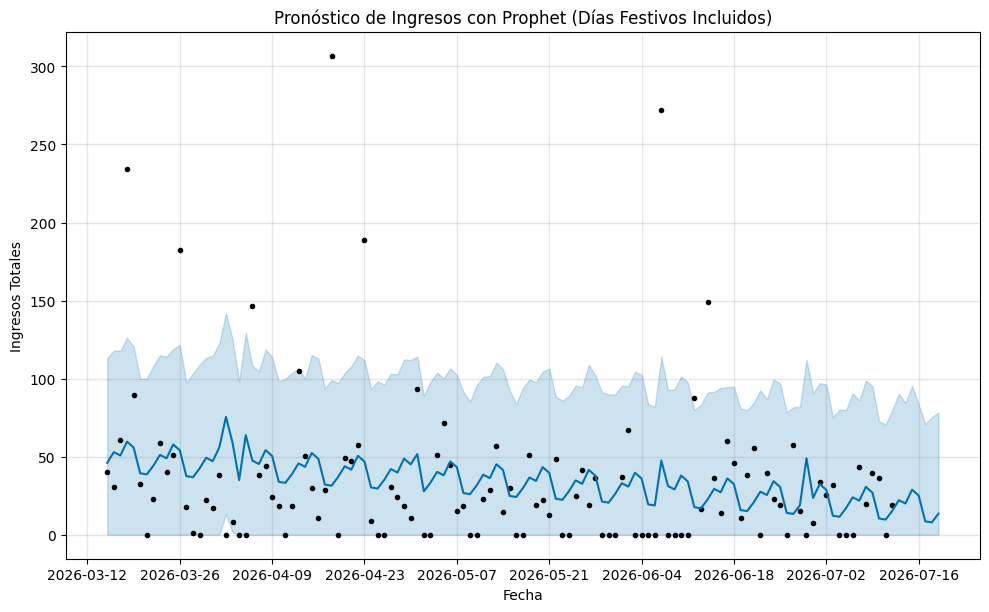

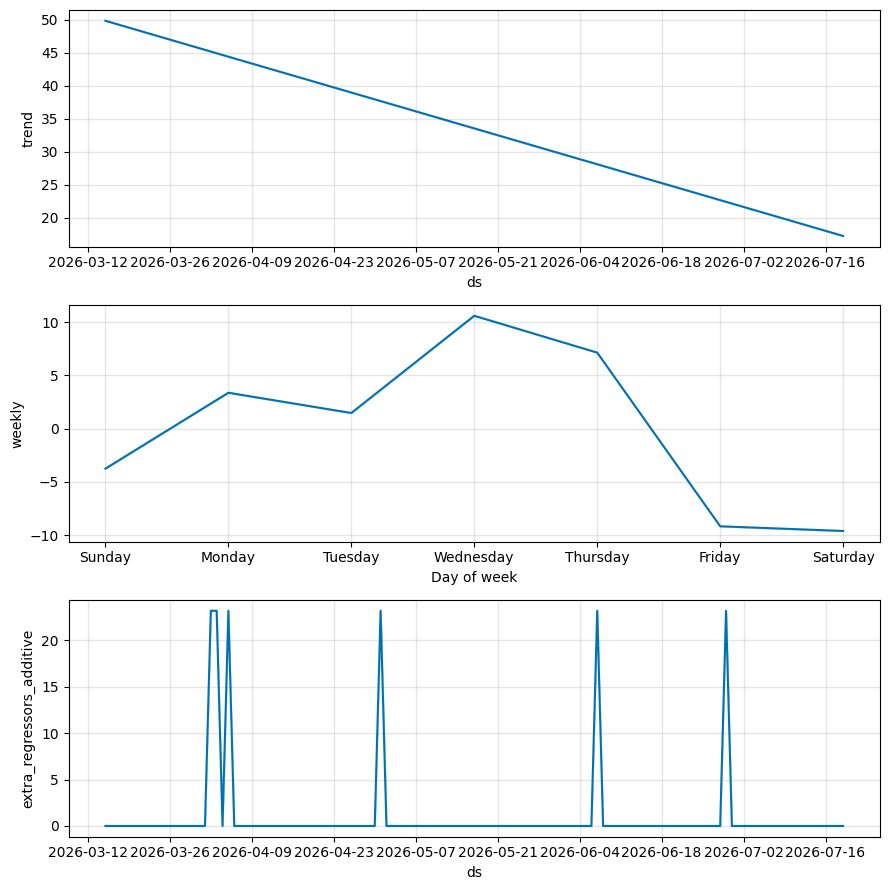

In [119]:
# Graficar el pronóstico de Prophet con valores ajustados y días festivos
fig_holidays = model_with_holidays.plot(forecast_with_holidays)
plt.title('Pronóstico de Ingresos con Prophet (Días Festivos Incluidos)')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales')
plt.show()

# Graficar los componentes del pronóstico de Prophet (tendencia, estacionalidad, festivos)
fig_components_holidays = model_with_holidays.plot_components(forecast_with_holidays)
plt.show()

In [120]:
# Dividir los datos con festivos para entrenamiento y evaluación
# Define test_size and test_df_original_y here as they are used in this cell
test_size = 30
test_df_original_y = df_prophet[-test_size:]

train_df_holidays = df_prophet_with_holidays[:-test_size]

print(f"Tamaño del conjunto de entrenamiento (con festivos): {len(train_df_holidays)} días")
print(f"Tamaño del conjunto de prueba (para evaluación): {len(test_df_original_y)} días")

Tamaño del conjunto de entrenamiento (con festivos): 90 días
Tamaño del conjunto de prueba (para evaluación): 30 días


In [121]:
# Re-entrenar el modelo Prophet con el conjunto de entrenamiento (con festivos)
model_eval_holidays = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=True,
    daily_seasonality=False
)

# Añadir el regressor extra para los días festivos
model_eval_holidays.add_regressor('is_holiday')

model_eval_holidays.fit(train_df_holidays)

print("Modelo Prophet con festivos re-entrenado para evaluación.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Modelo Prophet con festivos re-entrenado para evaluación.


In [122]:
# Crear un dataframe de fechas futuras que incluya el período de prueba
# Necesitamos las fechas y la columna 'is_holiday' para el conjunto de prueba.
future_eval_holidays = model_eval_holidays.make_future_dataframe(periods=test_size, freq='D', include_history=False)

# Asegurarse de que future_eval_holidays contenga la columna 'is_holiday'
# Para esto, necesitamos unirla con la parte correspondiente de df_prophet_with_holidays o generarla para el futuro.

# Generar los días festivos para las fechas futuras del conjunto de prueba
future_holidays_eval = holidays.country_holidays('PE', years=range(future_eval_holidays['ds'].min().year, future_eval_holidays['ds'].max().year + 1))
future_holidays_eval_df = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in future_holidays_eval.items()
])
future_holidays_eval_df['ds'] = pd.to_datetime(future_holidays_eval_df['ds'])

# Unir con el dataframe de fechas futuras para añadir la columna 'is_holiday'
future_eval_holidays = pd.merge(future_eval_holidays, future_holidays_eval_df, on='ds', how='left')
future_eval_holidays['is_holiday'] = future_eval_holidays['holiday'].notna().astype(int)
future_eval_holidays = future_eval_holidays.drop(columns=['holiday'])

# Realizar la predicción
forecast_eval_holidays = model_eval_holidays.predict(future_eval_holidays)

# Asegurarse de que las predicciones sean no-negativas
forecast_eval_holidays['yhat'] = forecast_eval_holidays['yhat'].apply(lambda x: max(x, 0))
forecast_eval_holidays['yhat_lower'] = forecast_eval_holidays['yhat_lower'].apply(lambda x: max(x, 0))
forecast_eval_holidays['yhat_upper'] = forecast_eval_holidays['yhat_upper'].apply(lambda x: max(x, 0))

print("Predicciones generadas para el conjunto de prueba con festivos:")
display(forecast_eval_holidays.head())

Predicciones generadas para el conjunto de prueba con festivos:


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,is_holiday,is_holiday_lower,is_holiday_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2026-06-13,19.743465,0.0,78.284905,19.743465,19.743465,-9.333625,-9.333625,-9.333625,0.0,...,0.0,0.0,0.0,-9.333625,-9.333625,-9.333625,0.0,0.0,0.0,10.409840
1,2026-06-14,19.409186,0.0,73.118200,19.409186,19.409186,-15.829160,-15.829160,-15.829160,0.0,...,0.0,0.0,0.0,-15.829160,-15.829160,-15.829160,0.0,0.0,0.0,3.580025
2,2026-06-15,19.074906,0.0,101.188349,19.074906,19.074906,12.921012,12.921012,12.921012,0.0,...,0.0,0.0,0.0,12.921012,12.921012,12.921012,0.0,0.0,0.0,31.995918
3,2026-06-16,18.740626,0.0,90.729404,18.740626,18.740626,3.795905,3.795905,3.795905,0.0,...,0.0,0.0,0.0,3.795905,3.795905,3.795905,0.0,0.0,0.0,22.536532
4,2026-06-17,18.406347,0.0,102.921510,18.406347,18.406347,12.626899,12.626899,12.626899,0.0,...,0.0,0.0,0.0,12.626899,12.626899,12.626899,0.0,0.0,0.0,31.033246


In [123]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import pandas as pd
import numpy as np
from prophet import Prophet
from dateutil import parser
import holidays # Added for holiday handling

# --- Start of code copied from FoJ6TqTslijr to define ingreso_diario_completo for local scope ---
# 1. Cargar el archivo de ventas
try:
    df_ventas = pd.read_csv('ventas.csv', sep=';')
except FileNotFoundError:
    df_ventas = pd.DataFrame({'Fecha': [], 'Total': []})

# 2. Normalización de Fechas
def parsear_fechas_cronologicas(fechas):
    fechas_limpias = []
    fecha_anterior = pd.Timestamp.min

    for fecha_str in fechas:
        if pd.isna(fecha_str):
            fechas_limpias.append(pd.NaT)
            continue
        try:
            fecha_dia_primero = parser.parse(fecha_str, dayfirst=True)
            fecha_mes_primero = parser.parse(fecha_str, dayfirst=False)

            if fecha_dia_primero == fecha_mes_primero:
                fecha_elegida = fecha_dia_primero
            else:
                valido_dia = fecha_dia_primero >= fecha_anterior
                valido_mes = fecha_mes_primero >= fecha_anterior

                if valido_dia and not valido_mes:
                    fecha_elegida = fecha_dia_primero
                elif valido_mes and not valido_dia:
                    fecha_elegida = fecha_mes_primero
                elif valido_dia and valido_mes:
                    if (fecha_dia_primero - fecha_anterior) < (fecha_mes_primero - fecha_anterior):
                        fecha_elegida = fecha_dia_primero
                    else:
                        fecha_elegida = fecha_mes_primero
                else:
                    diff_dia = fecha_anterior - fecha_dia_primero
                    diff_mes = fecha_anterior - fecha_mes_primero
                    fecha_elegida = fecha_dia_primero if diff_dia < diff_mes else fecha_mes_primero
            fechas_limpias.append(fecha_elegida)
            fecha_anterior = fecha_elegida
        except Exception:
            fechas_limpias.append(pd.NaT)
    return fechas_limpias

if 'Fecha' not in df_ventas.columns or 'Total' not in df_ventas.columns:
    ingreso_diario_completo = pd.DataFrame(columns=['Ingreso_Total'], index=pd.Index([], name='Fecha_Diaria'))
else:
    df_ventas['Fecha_Estandar'] = parsear_fechas_cronologicas(df_ventas['Fecha'])
    df_ventas['Fecha_Estandar'] = pd.to_datetime(df_ventas['Fecha_Estandar'])
    df_ventas.dropna(subset=['Fecha_Estandar'], inplace=True)
    df_ventas['Fecha_Diaria'] = df_ventas['Fecha_Estandar'].dt.normalize()

    # 3. Agrupación (Ingreso Diario)
    ingreso_diario = df_ventas.groupby('Fecha_Diaria')['Total'].sum().reset_index()
    ingreso_diario.rename(columns={'Total': 'Ingreso_Total'}, inplace=True)
    ingreso_diario.set_index('Fecha_Diaria', inplace=True)

    # 4. Manejo de días sin ventas (rellenar con 0)
    if not ingreso_diario.empty:
        min_date = ingreso_diario.index.min()
        max_date = ingreso_diario.index.max()
        full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')
        ingreso_diario_completo = ingreso_diario.reindex(full_date_range, fill_value=0)
        ingreso_diario_completo.index.name = 'Fecha_Diaria'
    else:
        ingreso_diario_completo = pd.DataFrame(columns=['Ingreso_Total'], index=pd.Index([], name='Fecha_Diaria'))
# --- End of code copied from FoJ6TqTslijr ---


# Re-create df_prophet for local scope if it's not globally available
# This code is copied from cell c2c84922
df_prophet = ingreso_diario_completo.reset_index()
df_prophet = df_prophet.rename(columns={'Fecha_Diaria': 'ds', 'Ingreso_Total': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['y'] = pd.to_numeric(df_prophet['y'])

# Re-create df_prophet_bounded for local scope if it's not globally available
# This code is copied from cell 3f86a6ae
df_prophet_bounded = df_prophet.copy()
df_prophet_bounded['floor'] = 0

# Define test_size and test_df_original_y as they are used in this cell and might not be globally available
test_size = 30
test_df_original_y = df_prophet[-test_size:]

# --- Start of code copied from e3899c94 to define df_prophet_with_holidays for local scope ---
# Obtener el rango de fechas de nuestro DataFrame
min_date_holidays = df_prophet_bounded['ds'].min()
max_date_holidays = df_prophet_bounded['ds'].max()

# Generar los días festivos de Perú para el rango de fechas
pe_holidays = holidays.country_holidays('PE', years=range(min_date_holidays.year, max_date_holidays.year + 1))

# Crear un DataFrame con los días festivos
holidays_df = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in pe_holidays.items()
])

# Convertir 'ds' a datetime para asegurar que se puede unir
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

# Unir el DataFrame de festivos con df_prophet_bounded
df_prophet_with_holidays = pd.merge(df_prophet_bounded, holidays_df, on='ds', how='left')

# Crear una columna binaria para indicar si es festivo (1) o no (0)
df_prophet_with_holidays['is_holiday'] = df_prophet_with_holidays['holiday'].notna().astype(int)

# Eliminar la columna 'holiday' ya que ya tenemos 'is_holiday'
df_prophet_with_holidays = df_prophet_with_holidays.drop(columns=['holiday'])
# --- End of code copied from e3899c94 ---

# --- Start of code copied from 1781b619 to define train_df_holidays for local scope ---
train_df_holidays = df_prophet_with_holidays[:-test_size]
# --- End of code copied from 1781b619 ---

# --- Start of code copied from 8ed74ae6 to define model_eval_holidays for local scope ---
model_eval_holidays = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=True,
    daily_seasonality=False
)
model_eval_holidays.add_regressor('is_holiday')
model_eval_holidays.fit(train_df_holidays)
# --- End of code copied from 8ed74ae6 ---

# --- Start of code copied from 7e2958de to define forecast_eval_holidays for local scope ---
future_eval_holidays = model_eval_holidays.make_future_dataframe(periods=test_size, freq='D', include_history=False)
future_holidays_eval = holidays.country_holidays('PE', years=range(future_eval_holidays['ds'].min().year, future_eval_holidays['ds'].max().year + 1))
future_holidays_eval_df = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in future_holidays_eval.items()
])
future_holidays_eval_df['ds'] = pd.to_datetime(future_holidays_eval_df['ds'])
future_eval_holidays = pd.merge(future_eval_holidays, future_holidays_eval_df, on='ds', how='left')
future_eval_holidays['is_holiday'] = future_eval_holidays['holiday'].notna().astype(int)
future_eval_holidays = future_eval_holidays.drop(columns=['holiday'])
forecast_eval_holidays = model_eval_holidays.predict(future_eval_holidays)
forecast_eval_holidays['yhat'] = forecast_eval_holidays['yhat'].apply(lambda x: max(x, 0))
forecast_eval_holidays['yhat_lower'] = forecast_eval_holidays['yhat_lower'].apply(lambda x: max(x, 0))
forecast_eval_holidays['yhat_upper'] = forecast_eval_holidays['yhat_upper'].apply(lambda x: max(x, 0))
# --- End of code copied from 7e2958de ---

# Unir las predicciones con los valores reales del conjunto de prueba
performance_df_holidays = pd.merge(test_df_original_y, forecast_eval_holidays[['ds', 'yhat']], on='ds', how='left')
performance_df_holidays = performance_df_holidays.rename(columns={'y': 'y_true'})

# Asegurarse de que no haya NaN en las predicciones si merge falló en algún punto
performance_df_holidays.dropna(subset=['y_true', 'yhat'], inplace=True);

# Calcular RMSE para el modelo con festivos
rmse_prophet_holidays = np.sqrt(mean_squared_error(performance_df_holidays['y_true'], performance_df_holidays['yhat']))

# Calcular MAPE para el modelo con festivos
mape_prophet_holidays = mean_absolute_percentage_error(performance_df_holidays['y_true'].replace(0, 1), performance_df_holidays['yhat']);

# --- NEW: Prepare data and train BASE Prophet model (without holidays) for comparison ---
# Define train_df for the base model (test_size and test_df_original_y are available from 1781b619)
train_df = df_prophet_bounded[:-test_size]

# Train the base Prophet model (model_eval)
model_eval = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=True,
    daily_seasonality=False
)
model_eval.fit(train_df);

# Generate predictions for the base model (forecast_eval)
future_eval = model_eval.make_future_dataframe(periods=test_size, freq='D', include_history=False)
forecast_eval = model_eval.predict(future_eval)
forecast_eval['yhat'] = forecast_eval['yhat'].apply(lambda x: max(x, 0))
forecast_eval['yhat_lower'] = forecast_eval['yhat_lower'].apply(lambda x: max(x, 0))
forecast_eval['yhat_upper'] = forecast_eval['yhat_upper'].apply(lambda x: max(x, 0));

# --- Existing: Calculate metrics for BASE Prophet model ---
# Unir las predicciones con los valores reales del conjunto de prueba para el modelo base
performance_df = pd.merge(test_df_original_y, forecast_eval[['ds', 'yhat']], on='ds', how='left')
performance_df = performance_df.rename(columns={'y': 'y_true'})

# Asegurarse de que no haya NaN en las predicciones si merge falló en algún punto
performance_df.dropna(subset=['y_true', 'yhat'], inplace=True);

# Calcular RMSE para el modelo base
rmse_prophet = np.sqrt(mean_squared_error(performance_df['y_true'], performance_df['yhat']))

# Calcular MAPE para el modelo base
mape_prophet = mean_absolute_percentage_error(performance_df['y_true'].replace(0, 1), performance_df['yhat']);


print(f"Prophet (con festivos) RMSE en el conjunto de prueba: {rmse_prophet_holidays:.2f}")
print(f"Prophet (con festivos) MAPE en el conjunto de prueba: {mape_prophet_holidays:.2%}")

print(f"\nComparación con el modelo Prophet base (sin festivos):")
print(f"Prophet (base) RMSE en el conjunto de prueba: {rmse_prophet:.2f}")
print(f"Prophet (base) MAPE en el conjunto de prueba: {mape_prophet:.2%}")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Prophet (con festivos) RMSE en el conjunto de prueba: 36.90
Prophet (con festivos) MAPE en el conjunto de prueba: 489.21%

Comparación con el modelo Prophet base (sin festivos):
Prophet (base) RMSE en el conjunto de prueba: 33.60
Prophet (base) MAPE en el conjunto de prueba: 312.47%


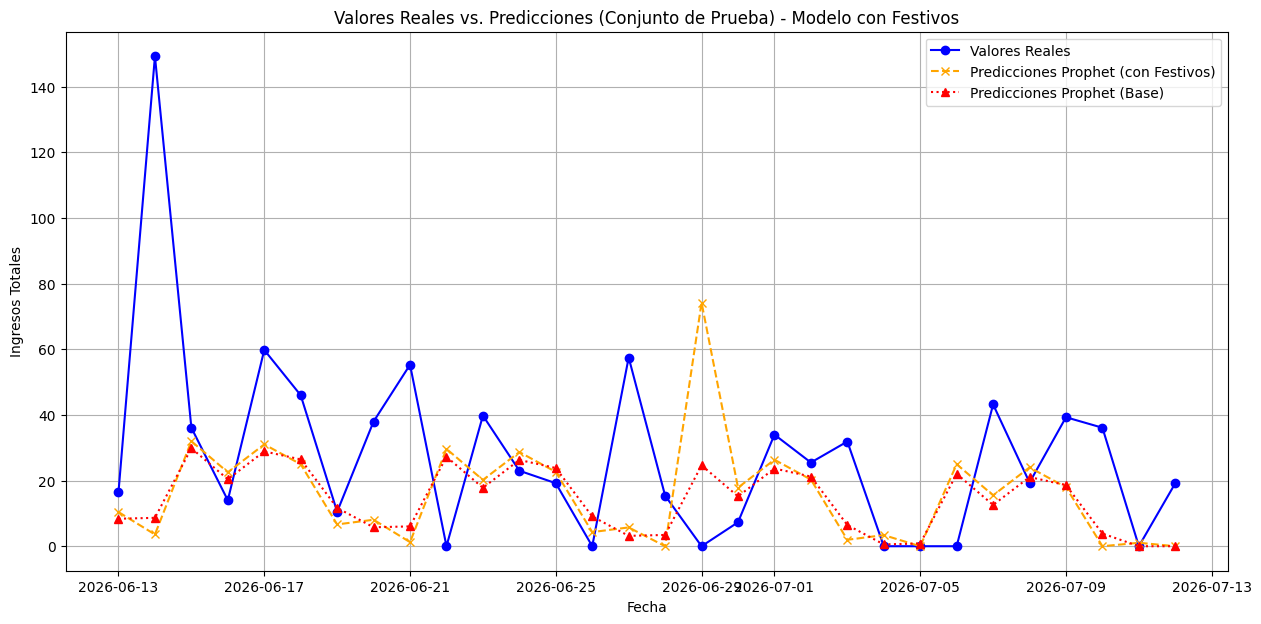

In [124]:
import matplotlib.pyplot as plt

# Visualizar las predicciones del conjunto de prueba vs. valores reales con el modelo de festivos
plt.figure(figsize=(15, 7))
plt.plot(performance_df_holidays['ds'], performance_df_holidays['y_true'], label='Valores Reales', color='blue', marker='o')
plt.plot(performance_df_holidays['ds'], performance_df_holidays['yhat'], label='Predicciones Prophet (con Festivos)', color='orange', linestyle='--', marker='x')
plt.plot(performance_df['ds'], performance_df['yhat'], label='Predicciones Prophet (Base)', color='red', linestyle=':', marker='^')
plt.title('Valores Reales vs. Predicciones (Conjunto de Prueba) - Modelo con Festivos')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales')
plt.legend()
plt.grid(True)
plt.show()

## Estrategias para Mejorar la Precisión del Modelo Prophet

Dado que los valores de MAPE son altos, hay varias áreas en las que podemos trabajar para mejorar la precisión del modelo Prophet:

1.  **Afinación de Hiperparámetros (Hyperparameter Tuning)**:
    *   Prophet tiene varios hiperparámetros que pueden ajustarse para mejorar el rendimiento, como:
        *   `changepoint_prior_scale`: Ajusta la flexibilidad del término de tendencia. Un valor más alto permite que la tendencia cambie más. (Rango común: 0.001 - 0.5)
        *   `seasonality_prior_scale`: Controla la flexibilidad de la estacionalidad. Un valor más alto permite que la estacionalidad se ajuste más a los datos. (Rango común: 0.01 - 10)
        *   `holidays_prior_scale`: Si se usan días festivos personalizados, ajusta su impacto. (Rango común: 0.01 - 10)
        *   `seasonality_mode`: Puede ser 'additive' o 'multiplicative'. La estacionalidad aditiva es constante a lo largo del tiempo, mientras que la multiplicativa crece o decrece con la tendencia. Para datos de ventas, a menudo la multiplicativa funciona mejor si las fluctuaciones estacionales son un porcentaje del total.
        *   `growth`: Puede ser 'linear' o 'logistic'. 'Logistic' se usa si hay un límite superior de crecimiento. Si no hay un límite claro, 'linear' es la opción por defecto.

2.  **Incorporar más Regresores Externos (Features)**:
    *   Además de los días festivos, ¿existen otros factores externos que puedan influir en las ventas? Por ejemplo:
        *   **Eventos especiales/promociones**: Días específicos con ofertas.
        *   **Condiciones económicas**: Indicadores económicos.
        *   **Factores climáticos**: Si el clima influye en las ventas.
        *   **Días de pago**: Si hay patrones de ventas alrededor de quincenas o fines de mes.

3.  **Manejo de Outliers (Valores Atípicos)**:
    *   Valores de venta extremadamente altos o bajos que no son representativos pueden distorsionar el modelo. Prophet es robusto a los outliers, pero si son muy extremos o frecuentes, podría ser útil tratarlos (por ejemplo, reemplazar con la mediana o eliminar).

4.  **Considerar otros Tipos de Estacionalidad**: Si hay patrones específicos que no son semanales o anuales, se pueden añadir estacionalidades personalizadas (por ejemplo, estacionalidad mensual si no está implícita en la semanal/anual).

5.  **Transformación de Datos**: A veces, aplicar una transformación logarítmica a la serie `y` puede ayudar a estabilizar la varianza y hacer que el modelo aditivo de Prophet funcione mejor, especialmente si la estacionalidad es multiplicativa (aunque Prophet permite `seasonality_mode='multiplicative'`).

Comenzaremos con la **Afinación de Hiperparámetros**.

### 2. Incorporar más Regresores Externos (Features)

Además de los días festivos, considera añadir otros factores que puedan influir en las ventas. Esto puede ser crucial para capturar variaciones no explicadas por la estacionalidad y la tendencia básica. Algunas ideas incluyen:

*   **Eventos especiales/Promociones:** Si hay días específicos donde se realizan descuentos, lanzamientos de productos o eventos de marketing, estos pueden ser agregados como regresores binarios o de impacto.
*   **Condiciones económicas:** Indicadores económicos como el IPC, tasas de interés, o encuestas de confianza del consumidor pueden influir en el poder adquisitivo.
*   **Factores climáticos:** Para ciertos productos, el clima (temperatura, lluvia, etc.) puede ser un factor importante. Por ejemplo, la venta de helados o bebidas refrescantes en días calurosos.
*   **Días de pago:** Los patrones de consumo a menudo cambian en las quincenas o fines de mes debido al pago de salarios.
*   **Vacaciones escolares:** En el caso de productos relacionados con el sector educativo o familiar, los períodos de vacaciones escolares pueden tener un impacto significativo.

### 3. Manejo de Outliers (Valores Atípicos)

Aunque Prophet es robusto a los outliers, valores extremadamente atípicos pueden distorsionar el modelo, especialmente si la frecuencia de los datos es baja o si el tamaño del conjunto de datos es pequeño. Puedes considerar las siguientes aproximaciones:

*   **Identificación visual:** Grafica la serie de tiempo y busca picos o caídas inusuales.
*   **Técnicas estadísticas:** Métodos como el IQR (Rango Intercuartílico) o la desviación estándar pueden ayudar a identificar outliers.
*   **Tratamiento:**
    *   **Reemplazo:** Sustituye los outliers por la mediana, la media de los días circundantes, o mediante una interpolación.
    *   **Eliminación (con precaución):** Si son errores de registro evidentes, se pueden eliminar. Sin embargo, si son eventos reales (ej. Black Friday, grandes lanzamientos), es mejor tratarlos como regresores externos o "días festivos" especiales.
    *   **Limitar (Clipping):** Establecer un umbral superior e inferior para los valores de `y`.

### 4. Considerar otros Tipos de Estacionalidad

Si bien has incluido la estacionalidad semanal, considera si existen otros ciclos que no estén siendo capturados:

*   **Estacionalidad anual:** Aunque los datos son de solo unos meses, si tu horizonte de predicción es a más largo plazo o si hay patrones que se repiten cada año (ej. Navidad, Día de la Madre), deberías habilitar `yearly_seasonality=True` en Prophet.
*   **Estacionalidad mensual/trimestral:** Para algunos negocios, las ventas pueden tener picos o valles consistentes en ciertos meses o trimestres del año que no están completamente explicados por la estacionalidad semanal o anual genérica. Prophet permite añadir estacionalidades personalizadas usando `model.add_seasonality()`.

### 5. Transformación de Datos

Si la varianza de la serie de tiempo no es constante (es decir, las fluctuaciones se hacen más grandes a medida que el valor de la serie aumenta), o si la estacionalidad es multiplicativa (el tamaño de la estacionalidad aumenta con la tendencia), una transformación logarítmica de la variable `y` puede ser beneficiosa. Esto puede ayudar a:

*   **Estabilizar la varianza:** Hacer que las fluctuaciones sean más uniformes.
*   **Convertir la estacionalidad multiplicativa en aditiva:** Si aplicas un logaritmo, un patrón multiplicativo se vuelve aditivo, lo que a menudo mejora el rendimiento del modelo Prophet cuando `seasonality_mode='additive'`.

Para implementar la transformación de datos, necesitarías:

1.  Aplicar `np.log(df_prophet['y'])` a la variable objetivo `y` antes de ajustar el modelo.
2.  Asegurarte de que no haya valores cero o negativos en `y` antes de aplicar el logaritmo (puedes añadir una pequeña constante, `np.log(y + 1)`).
3.  Transformar las predicciones (`yhat`, `yhat_lower`, `yhat_upper`) de nuevo a la escala original usando `np.exp()` después de la predicción.

### Implementando la Transformación Logarítmica

Procederemos a aplicar `np.log1p()` a la columna `y` (ventas). `log1p` es una función logarítmica que maneja correctamente los valores de cero (sumando 1 antes de aplicar el logaritmo), evitando errores con `log(0)`. Luego, entrenaremos y evaluaremos el modelo con esta transformación, y finalmente, revertiremos la transformación para obtener las predicciones en la escala original.

In [125]:
import numpy as np

# 1. Aplicar transformación logarítmica a 'y'
# Usamos log1p para manejar valores cero (log(y+1))
df_prophet_log = df_prophet_with_holidays.copy()
df_prophet_log['y'] = np.log1p(df_prophet_log['y'])

print("DataFrame con 'y' transformada logarítmicamente (primeras 5 filas):")
display(df_prophet_log.head())

DataFrame con 'y' transformada logarítmicamente (primeras 5 filas):


,ds,y,floor,is_holiday
0,2026-03-15,3.718438,0,0
1,2026-03-16,3.443618,0,0
2,2026-03-17,4.125520,0,0
3,2026-03-18,5.461711,0,0
4,2026-03-19,4.506454,0,0


### Reentrenamiento del Modelo con Datos Transformados

Ahora, reentrenaremos el modelo Prophet utilizando los datos de ventas transformados logarítmicamente. Esto permitirá al modelo capturar mejor las relaciones si la estacionalidad o los errores son de naturaleza multiplicativa.

In [126]:
# Dividir los datos transformados para entrenamiento y evaluación
train_df_log = df_prophet_log[:-test_size]

# Re-entrenar el modelo Prophet con el conjunto de entrenamiento logarítmico
model_log_holidays = Prophet(
    growth='linear',
    seasonality_mode='additive', # Prophet asume aditivo en la escala logarítmica
    weekly_seasonality=True,
    daily_seasonality=False
)

# Añadir el regressor extra para los días festivos
model_log_holidays.add_regressor('is_holiday')

model_log_holidays.fit(train_df_log)

print("Modelo Prophet re-entrenado con datos logarítmicos y regressor de días festivos para evaluación.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Modelo Prophet re-entrenado con datos logarítmicos y regressor de días festivos para evaluación.


### Generación de Predicciones y Transformación Inversa

Generaremos las predicciones en la escala logarítmica y luego las revertiremos a la escala original utilizando `np.expm1()` (`exp(y)-1`), que es la inversa de `np.log1p()`.

In [127]:
# Crear un dataframe de fechas futuras para la predicción (conjunto de prueba)
future_eval_log = model_log_holidays.make_future_dataframe(periods=test_size, freq='D', include_history=False)

# Añadir la columna 'is_holiday' al dataframe futuro de la misma manera que antes
# (copiamos el proceso de future_eval_holidays ya que es idéntico para las fechas de prueba)
future_eval_log = pd.merge(future_eval_log, future_holidays_eval_df, on='ds', how='left')
future_eval_log['is_holiday'] = future_eval_log['holiday'].notna().astype(int)
future_eval_log = future_eval_log.drop(columns=['holiday'])

# Realizar la predicción en escala logarítmica
forecast_log_holidays = model_log_holidays.predict(future_eval_log)

# Revertir la transformación logarítmica a la escala original (expm1 es la inversa de log1p)
forecast_log_holidays['yhat_original'] = np.expm1(forecast_log_holidays['yhat'])
forecast_log_holidays['yhat_lower_original'] = np.expm1(forecast_log_holidays['yhat_lower'])
forecast_log_holidays['yhat_upper_original'] = np.expm1(forecast_log_holidays['yhat_upper'])

# Asegurarse de que las predicciones originales sean no-negativas
forecast_log_holidays['yhat_original'] = forecast_log_holidays['yhat_original'].apply(lambda x: max(x, 0))
forecast_log_holidays['yhat_lower_original'] = forecast_log_holidays['yhat_lower_original'].apply(lambda x: max(x, 0))
forecast_log_holidays['yhat_upper_original'] = forecast_log_holidays['yhat_upper_original'].apply(lambda x: max(x, 0))

print("Predicciones generadas y revertidas a escala original (primeras 5 filas):")
display(forecast_log_holidays[['ds', 'yhat_original', 'yhat_lower_original', 'yhat_upper_original']].head())

Predicciones generadas y revertidas a escala original (primeras 5 filas):


,ds,yhat_original,yhat_lower_original,yhat_upper_original
0,2026-06-13,0.000000,0.000000,2.832475
1,2026-06-14,0.128936,0.000000,4.618767
2,2026-06-15,10.853496,0.970626,63.526427
3,2026-06-16,9.513330,0.899644,70.217411
4,2026-06-17,7.530746,0.561335,44.597261


### Evaluación del Modelo con Transformación Logarítmica

Finalmente, evaluaremos el rendimiento del modelo transformado utilizando el RMSE y el MAPE en la escala original, para comparar directamente con los modelos anteriores.

In [128]:
# Unir las predicciones con los valores reales del conjunto de prueba (originales)
performance_df_log = pd.merge(test_df_original_y, forecast_log_holidays[['ds', 'yhat_original']], on='ds', how='left')
performance_df_log = performance_df_log.rename(columns={'y': 'y_true', 'yhat_original': 'yhat'})

# Asegurarse de que no haya NaN en las predicciones si merge falló
performance_df_log.dropna(subset=['y_true', 'yhat'], inplace=True)

# Calcular RMSE para el modelo con transformación logarítmica
rmse_prophet_log = np.sqrt(mean_squared_error(performance_df_log['y_true'], performance_df_log['yhat']))

# Calcular MAPE para el modelo con transformación logarítmica
# Usamos .replace(0, 1) en y_true para evitar divisiones por cero si hay valores de 0
mape_prophet_log = mean_absolute_percentage_error(performance_df_log['y_true'].replace(0, 1), performance_df_log['yhat'])

print(f"Prophet (con festivos y log-transformado) RMSE en el conjunto de prueba: {rmse_prophet_log:.2f}")
print(f"Prophet (con festivos y log-transformado) MAPE en el conjunto de prueba: {mape_prophet_log:.2%}")

print(f"\nComparación con el modelo Prophet base (sin festivos):\n  RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2%}")
print(f"Comparación con el modelo Prophet (con festivos):\n  RMSE: {rmse_prophet_holidays:.2f}, MAPE: {mape_prophet_holidays:.2%}")

Prophet (con festivos y log-transformado) RMSE en el conjunto de prueba: 38.37
Prophet (con festivos y log-transformado) MAPE en el conjunto de prueba: 158.39%

Comparación con el modelo Prophet base (sin festivos):
  RMSE: 33.60, MAPE: 312.47%
Comparación con el modelo Prophet (con festivos):
  RMSE: 36.90, MAPE: 489.21%


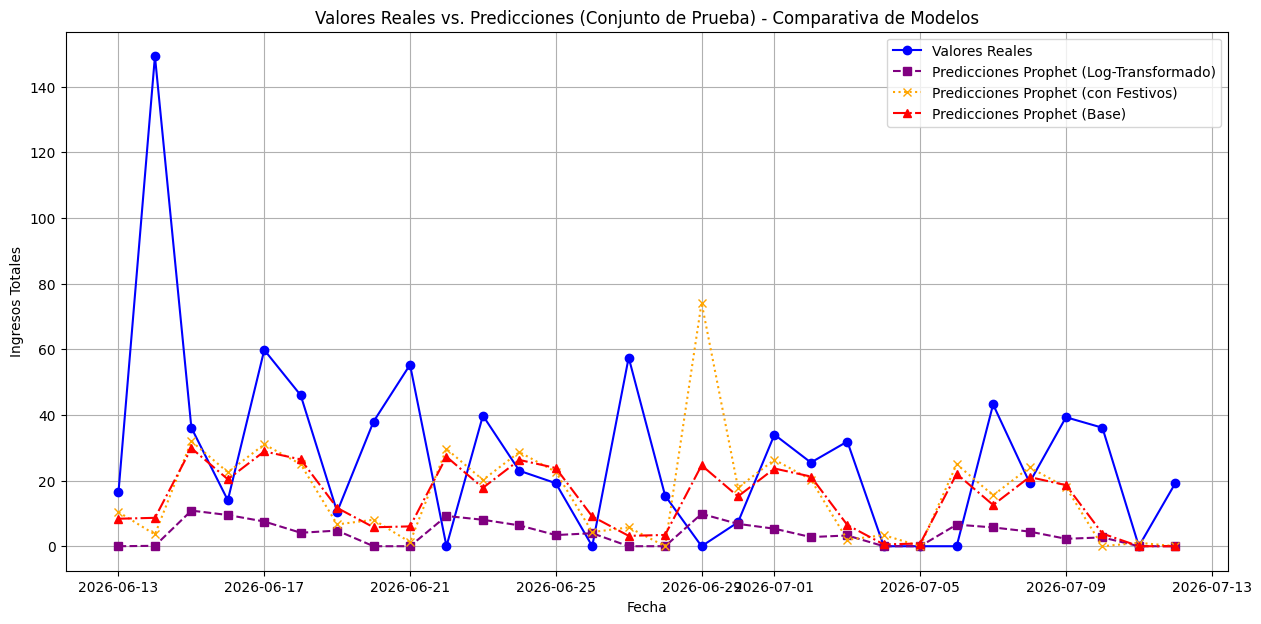

In [129]:
# Visualizar las predicciones del conjunto de prueba vs. valores reales con el modelo log-transformado
plt.figure(figsize=(15, 7))
plt.plot(performance_df_log['ds'], performance_df_log['y_true'], label='Valores Reales', color='blue', marker='o')
plt.plot(performance_df_log['ds'], performance_df_log['yhat'], label='Predicciones Prophet (Log-Transformado)', color='purple', linestyle='--', marker='s')
plt.plot(performance_df_holidays['ds'], performance_df_holidays['yhat'], label='Predicciones Prophet (con Festivos)', color='orange', linestyle=':', marker='x')
plt.plot(performance_df['ds'], performance_df['yhat'], label='Predicciones Prophet (Base)', color='red', linestyle='-.', marker='^')
plt.title('Valores Reales vs. Predicciones (Conjunto de Prueba) - Comparativa de Modelos')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales')
plt.legend()
plt.grid(True)
plt.show()

### 6. Incorporar Vacaciones y Campañas Escolares como Regresores Externos

Vamos a añadir las fechas de vacaciones y campañas escolares como nuevos regresores al modelo Prophet. Para ello, primero necesitamos definir estas fechas. Como no tenemos acceso a calendarios escolares en tiempo real, utilizaremos fechas hipotéticas para el año 2026. Puedes ajustarlas con las fechas reales cuando las tengas.

In [130]:
import pandas as pd

# Definir fechas hipotéticas de vacaciones y campañas escolares para 2026 (Perú)
# Puedes ajustar estas fechas según el calendario real de Perú
school_holidays_data = [
    {'holiday': 'Vacaciones de Verano', 'ds': '2026-01-01', 'upper_window': 0, 'lower_window': 58},
    {'holiday': 'Campaña Escolar Inicio', 'ds': '2026-03-01', 'upper_window': 7, 'lower_window': 30}, # Antes y después del inicio de clases
    {'holiday': 'Vacaciones de Medio Año', 'ds': '2026-07-26', 'upper_window': 7, 'lower_window': 14},
    {'holiday': 'Campaña Escolar Fiestas Patrias', 'ds': '2026-07-28', 'upper_window': 7, 'lower_window': 7},
    {'holiday': 'Vacaciones de Fin de Año', 'ds': '2026-12-15', 'upper_window': 15, 'lower_window': 0},
    {'holiday': 'Campaña Escolar Navidad', 'ds': '2026-12-01', 'upper_window': 24, 'lower_window': 0}
]

school_holidays_df = pd.DataFrame(school_holidays_data)
school_holidays_df['ds'] = pd.to_datetime(school_holidays_df['ds'])

print("Fechas hipotéticas de vacaciones y campañas escolares:")
display(school_holidays_df)


Fechas hipotéticas de vacaciones y campañas escolares:


,holiday,ds,upper_window,lower_window
0,Vacaciones de Verano,2026-01-01,0,58
1,Campaña Escolar Inicio,2026-03-01,7,30
2,Vacaciones de Medio Año,2026-07-26,7,14
3,Campaña Escolar Fiestas Patrias,2026-07-28,7,7
4,Vacaciones de Fin de Año,2026-12-15,15,0
5,Campaña Escolar Navidad,2026-12-01,24,0


### Combinar Festivos Nacionales y Escolares

Ahora combinaremos el dataframe de festivos nacionales (`holidays_df` que ya habíamos creado) con este nuevo dataframe de vacaciones/campañas escolares. Luego, crearemos un único regressor binario `is_any_holiday` o mantendremos `is_holiday` y `is_school_holiday` por separado para un análisis más granular.

In [131]:
# Para evitar errores de re-definición de df_prophet_with_holidays, lo recreamos localmente
# (o nos aseguramos de que esté disponible en el entorno global)

# Obtener el rango de fechas de nuestro DataFrame
min_date_all_holidays = df_prophet_bounded['ds'].min()
max_date_all_holidays = df_prophet_bounded['ds'].max()

# Generar los días festivos de Perú para el rango de fechas (ya se hizo antes)
pe_holidays_combined = holidays.country_holidays('PE', years=range(min_date_all_holidays.year, max_date_all_holidays.year + 1))

# Crear un DataFrame con los días festivos nacionales
holidays_df_national = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in pe_holidays_combined.items()
])
holidays_df_national['ds'] = pd.to_datetime(holidays_df_national['ds'])

# Unir ambos dataframes de festivos
# Usamos outer merge para incluir todos los festivos de ambos sets
all_holidays_df = pd.concat([holidays_df_national, school_holidays_df.drop(columns=['upper_window', 'lower_window'])], ignore_index=True)
all_holidays_df = all_holidays_df.drop_duplicates(subset=['ds', 'holiday']).sort_values('ds')


# Preparar df_prophet con el regressor combinado
df_prophet_with_all_holidays = df_prophet_bounded.copy()
df_prophet_with_all_holidays = pd.merge(df_prophet_with_all_holidays, all_holidays_df[['ds', 'holiday']], on='ds', how='left')

# Crear una columna binaria para indicar si es CUALQUIER tipo de festivo (nacional o escolar)
df_prophet_with_all_holidays['is_any_holiday'] = df_prophet_with_all_holidays['holiday'].notna().astype(int)

# Crear una columna binaria específica para festivos escolares (usando el 'holiday' para identificar)
df_prophet_with_all_holidays['is_school_holiday'] = df_prophet_with_all_holidays['holiday'].apply(lambda x: 1 if pd.notna(x) and ('Vacaciones' in x or 'Campaña' in x) else 0)

# La columna 'is_holiday' anterior en `df_prophet_with_holidays` ya representaba festivos nacionales.
# Para este nuevo modelo, usaremos `is_any_holiday` y `is_school_holiday` si queremos separar el efecto.
# Por simplicidad, agregaremos 'is_school_holiday' como un regressor adicional al modelo que ya usa `is_holiday` (nacional).

# Podemos recrear df_prophet_with_holidays para que 'is_holiday' se refiera solo a nacionales
df_prophet_with_national_holidays = pd.merge(df_prophet_bounded.copy(), holidays_df_national, on='ds', how='left')
df_prophet_with_national_holidays['is_holiday'] = df_prophet_with_national_holidays['holiday'].notna().astype(int)
df_prophet_with_national_holidays = df_prophet_with_national_holidays.drop(columns=['holiday'])

# Ahora, combinamos df_prophet_with_national_holidays con el regressor de vacaciones escolares
df_prophet_final_holidays = pd.merge(df_prophet_with_national_holidays, df_prophet_with_all_holidays[['ds', 'is_school_holiday']], on='ds', how='left')

print("DataFrame con festivos nacionales e indicadores de vacaciones/campañas escolares (primeras 5 filas):")
display(df_prophet_final_holidays.head())
print("DataFrame con festivos nacionales e indicadores de vacaciones/campañas escolares (últimas 5 filas):")
display(df_prophet_final_holidays.tail())


DataFrame con festivos nacionales e indicadores de vacaciones/campañas escolares (primeras 5 filas):


,ds,y,floor,is_holiday,is_school_holiday
0,2026-03-15,40.2,0,0,0
1,2026-03-16,30.3,0,0,0
2,2026-03-17,60.9,0,0,0
3,2026-03-18,234.5,0,0,0
4,2026-03-19,89.6,0,0,0


DataFrame con festivos nacionales e indicadores de vacaciones/campañas escolares (últimas 5 filas):


,ds,y,floor,is_holiday,is_school_holiday
115,2026-07-08,19.4,0,0,0
116,2026-07-09,39.3,0,0,0
117,2026-07-10,36.1,0,0,0
118,2026-07-11,0.0,0,0,0
119,2026-07-12,19.2,0,0,0


### Preparación y Reentrenamiento del Modelo Prophet con Nuevos Regresores

Ahora, prepararemos los datos con la transformación logarítmica y los nuevos regresores (`is_holiday` para nacionales y `is_school_holiday` para escolares). Luego, reentrenaremos el modelo Prophet con estos regresores adicionales.

In [132]:
# 1. Aplicar transformación logarítmica a 'y' en el nuevo df
df_prophet_log_final_holidays = df_prophet_final_holidays.copy()
df_prophet_log_final_holidays['y'] = np.log1p(df_prophet_log_final_holidays['y'])

# Dividir los datos transformados para entrenamiento y evaluación
train_df_log_final_holidays = df_prophet_log_final_holidays[:-test_size]

# Re-entrenar el modelo Prophet con el conjunto de entrenamiento logarítmico
model_log_all_holidays = Prophet(
    growth='linear',
    seasonality_mode='additive', # Prophet asume aditivo en la escala logarítmica
    weekly_seasonality=True,
    daily_seasonality=False
)

# Añadir los regresores extras para los días festivos nacionales y escolares
model_log_all_holidays.add_regressor('is_holiday') # Regresor para festivos nacionales
model_log_all_holidays.add_regressor('is_school_holiday') # Regresor para vacaciones/campañas escolares

model_log_all_holidays.fit(train_df_log_final_holidays)

print("Modelo Prophet re-entrenado con datos logarítmicos, festivos nacionales y escolares.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Modelo Prophet re-entrenado con datos logarítmicos, festivos nacionales y escolares.


### Generación de Predicciones y Transformación Inversa (con Festivos Nacionales y Escolares)

Generaremos las predicciones en la escala logarítmica para el conjunto de prueba, incluyendo los nuevos regresores, y luego las revertiremos a la escala original.

In [133]:
# Crear un dataframe de fechas futuras para la predicción (conjunto de prueba)
future_eval_all_holidays = model_log_all_holidays.make_future_dataframe(periods=test_size, freq='D', include_history=False)

# Asegurarse de que future_eval_all_holidays contenga ambas columnas de regresores

# 1. Añadir festivos nacionales ('is_holiday')
future_holidays_eval_combined = holidays.country_holidays('PE', years=range(future_eval_all_holidays['ds'].min().year, future_eval_all_holidays['ds'].max().year + 1))
future_holidays_eval_df_national = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in future_holidays_eval_combined.items()
])
future_holidays_eval_df_national['ds'] = pd.to_datetime(future_holidays_eval_df_national['ds'])

future_eval_all_holidays = pd.merge(future_eval_all_holidays, future_holidays_eval_df_national[['ds', 'holiday']], on='ds', how='left')
future_eval_all_holidays['is_holiday'] = future_eval_all_holidays['holiday'].notna().astype(int)
future_eval_all_holidays = future_eval_all_holidays.drop(columns=['holiday'])

# 2. Añadir festivos escolares ('is_school_holiday')
# Re-crear el dataframe de school_holidays_df para el rango de fechas futuras si es necesario
# Para simplificar, asumiremos que las fechas escolares definidas al inicio cubren el rango de test_size
# Si school_holidays_df solo cubre el pasado, necesitaríamos extenderlo.

# Crear una lista de fechas que son "vacaciones escolares" o "campañas escolares" para el rango de predicción
school_campaign_dates_future = []
for _, row in school_holidays_df.iterrows():
    start_date = row['ds'] - pd.Timedelta(days=row['lower_window'])
    end_date = row['ds'] + pd.Timedelta(days=row['upper_window'])
    current_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    school_campaign_dates_future.extend(current_dates)

school_campaign_dates_future = pd.DataFrame({'ds': list(set(school_campaign_dates_future))}) # Eliminar duplicados
school_campaign_dates_future['is_school_holiday_flag'] = 1
school_campaign_dates_future['ds'] = pd.to_datetime(school_campaign_dates_future['ds'])

future_eval_all_holidays = pd.merge(future_eval_all_holidays, school_campaign_dates_future, on='ds', how='left')
future_eval_all_holidays['is_school_holiday'] = future_eval_all_holidays['is_school_holiday_flag'].fillna(0).astype(int)
future_eval_all_holidays = future_eval_all_holidays.drop(columns=['is_school_holiday_flag'])

# Realizar la predicción en escala logarítmica
forecast_log_all_holidays = model_log_all_holidays.predict(future_eval_all_holidays)

# Revertir la transformación logarítmica a la escala original
forecast_log_all_holidays['yhat_original'] = np.expm1(forecast_log_all_holidays['yhat'])
forecast_log_all_holidays['yhat_lower_original'] = np.expm1(forecast_log_all_holidays['yhat_lower'])
forecast_log_all_holidays['yhat_upper_original'] = np.expm1(forecast_log_all_holidays['yhat_upper'])

# Asegurarse de que las predicciones originales sean no-negativas
forecast_log_all_holidays['yhat_original'] = forecast_log_all_holidays['yhat_original'].apply(lambda x: max(x, 0))
forecast_log_all_holidays['yhat_lower_original'] = forecast_log_all_holidays['yhat_lower_original'].apply(lambda x: max(x, 0))
forecast_log_all_holidays['yhat_upper_original'] = forecast_log_all_holidays['yhat_upper_original'].apply(lambda x: max(x, 0))

print("Predicciones generadas y revertidas a escala original con festivos nacionales y escolares (primeras 5 filas):")
display(forecast_log_all_holidays[['ds', 'yhat_original', 'yhat_lower_original', 'yhat_upper_original']].head())

Predicciones generadas y revertidas a escala original con festivos nacionales y escolares (primeras 5 filas):


,ds,yhat_original,yhat_lower_original,yhat_upper_original
0,2026-06-13,0.000000,0.000000,3.326023
1,2026-06-14,0.128936,0.000000,5.484413
2,2026-06-15,10.853496,0.997528,68.601734
3,2026-06-16,9.513330,0.711636,55.575260
4,2026-06-17,7.530746,0.552002,55.837714


### Evaluación del Modelo con Festivos Nacionales y Escolares

Evaluaremos el rendimiento del modelo con ambos tipos de festivos y la transformación logarítmica.

In [134]:
# Unir las predicciones con los valores reales del conjunto de prueba (originales)
performance_df_all_holidays = pd.merge(test_df_original_y, forecast_log_all_holidays[['ds', 'yhat_original']], on='ds', how='left')
performance_df_all_holidays = performance_df_all_holidays.rename(columns={'y': 'y_true', 'yhat_original': 'yhat'})

# Asegurarse de que no haya NaN en las predicciones si merge falló
performance_df_all_holidays.dropna(subset=['y_true', 'yhat'], inplace=True)

# Calcular RMSE para el modelo con transformación logarítmica y todos los festivos
rmse_prophet_all_holidays = np.sqrt(mean_squared_error(performance_df_all_holidays['y_true'], performance_df_all_holidays['yhat']))

# Calcular MAPE para el modelo con transformación logarítmica y todos los festivos
mape_prophet_all_holidays = mean_absolute_percentage_error(performance_df_all_holidays['y_true'].replace(0, 1), performance_df_all_holidays['yhat'])

print(f"Prophet (log-transformado, festivos nacionales y escolares) RMSE en el conjunto de prueba: {rmse_prophet_all_holidays:.2f}")
print(f"Prophet (log-transformado, festivos nacionales y escolares) MAPE en el conjunto de prueba: {mape_prophet_all_holidays:.2%}")

print(f"\nComparación con el modelo Prophet base (sin festivos):\n  RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2%}")
print(f"Comparación con el modelo Prophet (con festivos nacionales):\n  RMSE: {rmse_prophet_holidays:.2f}, MAPE: {mape_prophet_holidays:.2%}")
print(f"Comparación con el modelo Prophet (log-transformado, festivos nacionales):\n  RMSE: {rmse_prophet_log:.2f}, MAPE: {mape_prophet_log:.2%}")

Prophet (log-transformado, festivos nacionales y escolares) RMSE en el conjunto de prueba: 38.37
Prophet (log-transformado, festivos nacionales y escolares) MAPE en el conjunto de prueba: 158.39%

Comparación con el modelo Prophet base (sin festivos):
  RMSE: 33.60, MAPE: 312.47%
Comparación con el modelo Prophet (con festivos nacionales):
  RMSE: 36.90, MAPE: 489.21%
Comparación con el modelo Prophet (log-transformado, festivos nacionales):
  RMSE: 38.37, MAPE: 158.39%


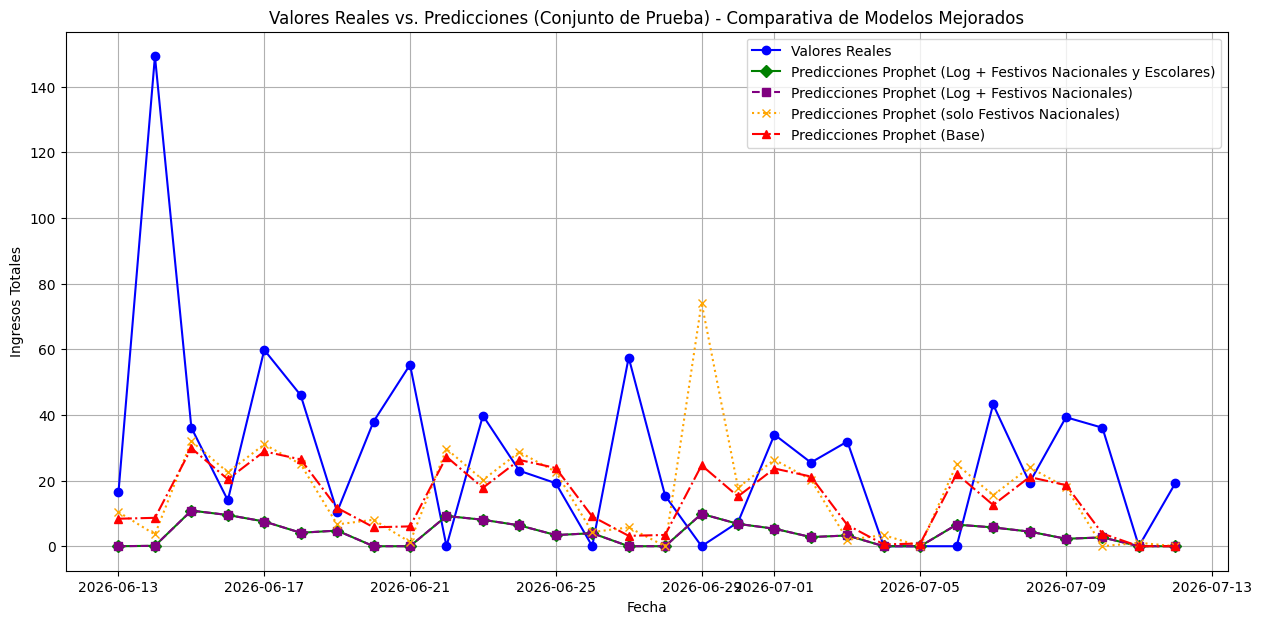

In [135]:
# Visualizar las predicciones del conjunto de prueba vs. valores reales con el modelo log-transformado y todos los festivos
plt.figure(figsize=(15, 7))
plt.plot(performance_df_all_holidays['ds'], performance_df_all_holidays['y_true'], label='Valores Reales', color='blue', marker='o')
plt.plot(performance_df_all_holidays['ds'], performance_df_all_holidays['yhat'], label='Predicciones Prophet (Log + Festivos Nacionales y Escolares)', color='green', linestyle='-', marker='D')
plt.plot(performance_df_log['ds'], performance_df_log['yhat'], label='Predicciones Prophet (Log + Festivos Nacionales)', color='purple', linestyle='--', marker='s')
plt.plot(performance_df_holidays['ds'], performance_df_holidays['yhat'], label='Predicciones Prophet (solo Festivos Nacionales)', color='orange', linestyle=':', marker='x')
plt.plot(performance_df['ds'], performance_df['yhat'], label='Predicciones Prophet (Base)', color='red', linestyle='-.', marker='^')
plt.title('Valores Reales vs. Predicciones (Conjunto de Prueba) - Comparativa de Modelos Mejorados')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales')
plt.legend()
plt.grid(True)
plt.show()

## Predicciones Semanales con Prophet

Procederemos a realizar predicciones semanales, lo que puede ser más adecuado para ciertos negocios donde las fluctuaciones diarias son altas pero hay patrones más claros a nivel semanal. Compararemos el rendimiento con los modelos diarios anteriores.

### 1. Agregación de Datos Diarios a Semanales

In [136]:
# Agrupar 'ingreso_diario_completo' por semana y sumar los ingresos
# La fecha de la semana será el inicio de la semana (por defecto, Lunes)
weekly_ingreso = ingreso_diario_completo.resample('W-MON')['Ingreso_Total'].sum().reset_index()

# Renombrar columnas para Prophet
weekly_df_prophet = weekly_ingreso.rename(columns={'Fecha_Diaria': 'ds', 'Ingreso_Total': 'y'})

# Asegurarse de que 'ds' sea datetime y 'y' sea numérico
weekly_df_prophet['ds'] = pd.to_datetime(weekly_df_prophet['ds'])
weekly_df_prophet['y'] = pd.to_numeric(weekly_df_prophet['y'])

print("Datos semanales preparados para Prophet (primeras 5 filas):")
display(weekly_df_prophet.head())

Datos semanales preparados para Prophet (primeras 5 filas):


,ds,y
0,2026-03-16,70.5
1,2026-03-23,499.1
2,2026-03-30,314.6
3,2026-04-06,210.0
4,2026-04-13,248.5


### 2. Incorporación de Regresores Semanales de Festivos

In [137]:
# Crear un indicador semanal para festivos nacionales
# Resample 'holidays_df_national' para ver si alguna semana contiene un festivo
# Re-creamos holidays_df_national just in case of local scope issues
min_date_all_holidays = df_prophet_bounded['ds'].min()
max_date_all_holidays = df_prophet_bounded['ds'].max()

pe_holidays_combined = holidays.country_holidays('PE', years=range(min_date_all_holidays.year, max_date_all_holidays.year + 1))
holidays_df_national = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in pe_holidays_combined.items()
])
holidays_df_national['ds'] = pd.to_datetime(holidays_df_national['ds'])

weekly_national_holidays = holidays_df_national.set_index('ds').resample('W-MON').apply(lambda x: 1 if len(x) > 0 else 0).rename(columns={'holiday': 'is_weekly_national_holiday'}).reset_index()

# Crear un indicador semanal para vacaciones y campañas escolares
# Re-create school_holidays_df just in case of local scope issues
school_holidays_data = [
    {'holiday': 'Vacaciones de Verano', 'ds': '2026-01-01', 'upper_window': 0, 'lower_window': 58},
    {'holiday': 'Campaña Escolar Inicio', 'ds': '2026-03-01', 'upper_window': 7, 'lower_window': 30}, # Antes y después del inicio de clases
    {'holiday': 'Vacaciones de Medio Año', 'ds': '2026-07-26', 'upper_window': 7, 'lower_window': 14},
    {'holiday': 'Campaña Escolar Fiestas Patrias', 'ds': '2026-07-28', 'upper_window': 7, 'lower_window': 7},
    {'holiday': 'Vacaciones de Fin de Año', 'ds': '2026-12-15', 'upper_window': 15, 'lower_window': 0},
    {'holiday': 'Campaña Escolar Navidad', 'ds': '2026-12-01', 'upper_window': 24, 'lower_window': 0}
]
school_holidays_df = pd.DataFrame(school_holidays_data)
school_holidays_df['ds'] = pd.to_datetime(school_holidays_df['ds'])


# Expandir las fechas de las vacaciones/campañas escolares a un rango diario
school_campaign_daily_dates = []
for _, row in school_holidays_df.iterrows():
    start_date = row['ds'] - pd.Timedelta(days=row['lower_window'])
    end_date = row['ds'] + pd.Timedelta(days=row['upper_window'])
    current_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    school_campaign_daily_dates.extend(current_dates)

school_campaign_daily_df = pd.DataFrame({'ds': list(set(school_campaign_daily_dates))})
school_campaign_daily_df['is_school_campaign_day'] = 1
school_campaign_daily_df['ds'] = pd.to_datetime(school_campaign_daily_df['ds'])

# Resample a semanal para ver si alguna semana contiene un día de vacaciones/campaña escolar
weekly_school_holidays = school_campaign_daily_df.set_index('ds').resample('W-MON').apply(lambda x: 1 if len(x) > 0 else 0).rename(columns={'is_school_campaign_day': 'is_weekly_school_holiday'}).reset_index()

# Unir los regresores semanales al dataframe semanal
weekly_df_prophet_with_holidays = pd.merge(weekly_df_prophet, weekly_national_holidays, on='ds', how='left')
weekly_df_prophet_with_holidays = pd.merge(weekly_df_prophet_with_holidays, weekly_school_holidays, on='ds', how='left')

# Rellenar NaNs con 0 para los regresores
weekly_df_prophet_with_holidays['is_weekly_national_holiday'] = weekly_df_prophet_with_holidays['is_weekly_national_holiday'].fillna(0).astype(int)
weekly_df_prophet_with_holidays['is_weekly_school_holiday'] = weekly_df_prophet_with_holidays['is_weekly_school_holiday'].fillna(0).astype(int)

print("Datos semanales con regresores de festivos (primeras 5 filas):")
display(weekly_df_prophet_with_holidays.head())

Datos semanales con regresores de festivos (primeras 5 filas):


,ds,y,is_weekly_national_holiday,is_weekly_school_holiday
0,2026-03-16,70.5,0,0
1,2026-03-23,499.1,0,0
2,2026-03-30,314.6,0,0
3,2026-04-06,210.0,1,0
4,2026-04-13,248.5,0,0


### 3. Aplicar Transformación Logarítmica a los Datos Semanales

In [138]:
# Aplicar np.log1p a la columna 'y' de los datos semanales
weekly_df_prophet_log = weekly_df_prophet_with_holidays.copy()
weekly_df_prophet_log['y'] = np.log1p(weekly_df_prophet_log['y'])

print("DataFrame semanal con 'y' transformada logarítmicamente (primeras 5 filas):")
display(weekly_df_prophet_log.head())

DataFrame semanal con 'y' transformada logarítmicamente (primeras 5 filas):


,ds,y,is_weekly_national_holiday,is_weekly_school_holiday
0,2026-03-16,4.269697,0,0
1,2026-03-23,6.214808,0,0
2,2026-03-30,5.754476,0,0
3,2026-04-06,5.351858,1,0
4,2026-04-13,5.519459,0,0


### 4. División de Datos y Entrenamiento del Modelo Prophet Semanal

In [139]:
# Definir el tamaño del conjunto de prueba en semanas (aproximadamente 30 días / 7 días/semana = 4.28 semanas)
test_size_weeks = 4

# Dividir los datos semanales transformados para entrenamiento y evaluación
train_weekly_df_log = weekly_df_prophet_log[:-test_size_weeks]
test_weekly_df_original_y = weekly_df_prophet_with_holidays[-test_size_weeks:] # Guardar y original para evaluación

# Re-entrenar el modelo Prophet con el conjunto de entrenamiento semanal logarítmico
model_weekly_log_holidays = Prophet(
    growth='linear',
    seasonality_mode='additive', # Prophet asume aditivo en la escala logarítmica
    weekly_seasonality=False, # No aplicar estacionalidad semanal, ya está en la agregación
    daily_seasonality=False, # No aplica a datos semanales
    yearly_seasonality=False # No suficiente data para estacionalidad anual
)

# Añadir los regresores extras para los días festivos nacionales y escolares (semanales)
model_weekly_log_holidays.add_regressor('is_weekly_national_holiday')
model_weekly_log_holidays.add_regressor('is_weekly_school_holiday')

model_weekly_log_holidays.fit(train_weekly_df_log)

print("Modelo Prophet re-entrenado con datos logarítmicos, festivos nacionales y escolares semanales.")

INFO:prophet:n_changepoints greater than number of observations. Using 10.


Modelo Prophet re-entrenado con datos logarítmicos, festivos nacionales y escolares semanales.


### 5. Generación de Predicciones y Transformación Inversa (Semanal)

In [140]:
# Crear un dataframe de fechas futuras para la predicción (conjunto de prueba semanal)
future_eval_weekly_holidays = model_weekly_log_holidays.make_future_dataframe(periods=test_size_weeks, freq='W-MON', include_history=False)

# Añadir los regresores semanales al dataframe futuro
future_eval_weekly_holidays = pd.merge(future_eval_weekly_holidays, weekly_national_holidays, on='ds', how='left')
future_eval_weekly_holidays = pd.merge(future_eval_weekly_holidays, weekly_school_holidays, on='ds', how='left')

# Rellenar NaNs con 0 para los regresores en el dataframe futuro
future_eval_weekly_holidays['is_weekly_national_holiday'] = future_eval_weekly_holidays['is_weekly_national_holiday'].fillna(0).astype(int)
future_eval_weekly_holidays['is_weekly_school_holiday'] = future_eval_weekly_holidays['is_weekly_school_holiday'].fillna(0).astype(int)

# Realizar la predicción en escala logarítmica
forecast_weekly_log_holidays = model_weekly_log_holidays.predict(future_eval_weekly_holidays)

# Revertir la transformación logarítmica a la escala original
forecast_weekly_log_holidays['yhat_original'] = np.expm1(forecast_weekly_log_holidays['yhat'])
forecast_weekly_log_holidays['yhat_lower_original'] = np.expm1(forecast_weekly_log_holidays['yhat_lower'])
forecast_weekly_log_holidays['yhat_upper_original'] = np.expm1(forecast_weekly_log_holidays['yhat_upper'])

# Asegurarse de que las predicciones originales sean no-negativas
forecast_weekly_log_holidays['yhat_original'] = forecast_weekly_log_holidays['yhat_original'].apply(lambda x: max(x, 0))
forecast_weekly_log_holidays['yhat_lower_original'] = forecast_weekly_log_holidays['yhat_lower_original'].apply(lambda x: max(x, 0))
forecast_weekly_log_holidays['yhat_upper_original'] = forecast_weekly_log_holidays['yhat_upper_original'].apply(lambda x: max(x, 0))

print("Predicciones semanales generadas y revertidas a escala original (primeras 5 filas):")
display(forecast_weekly_log_holidays[['ds', 'yhat_original', 'yhat_lower_original', 'yhat_upper_original']].head())

Predicciones semanales generadas y revertidas a escala original (primeras 5 filas):


,ds,yhat_original,yhat_lower_original,yhat_upper_original
0,2026-06-22,213.095180,109.787516,405.955350
1,2026-06-29,230.806008,118.641266,444.770241
2,2026-07-06,210.597634,108.760964,379.569029
3,2026-07-13,209.359808,102.595192,400.344906


### 6. Evaluación del Modelo Prophet Semanal

In [141]:
# Unir las predicciones semanales con los valores reales del conjunto de prueba (originales)
performance_weekly_df_log = pd.merge(test_weekly_df_original_y, forecast_weekly_log_holidays[['ds', 'yhat_original']], on='ds', how='left')
performance_weekly_df_log = performance_weekly_df_log.rename(columns={'y': 'y_true', 'yhat_original': 'yhat'})

# Asegurarse de que no haya NaN en las predicciones si merge falló
performance_weekly_df_log.dropna(subset=['y_true', 'yhat'], inplace=True)

# Calcular RMSE para el modelo semanal con transformación logarítmica y todos los festivos
rmse_prophet_weekly = np.sqrt(mean_squared_error(performance_weekly_df_log['y_true'], performance_weekly_df_log['yhat']))

# Calcular MAPE para el modelo semanal con transformación logarítmica y todos los festivos
mape_prophet_weekly = mean_absolute_percentage_error(performance_weekly_df_log['y_true'].replace(0, 1), performance_weekly_df_log['yhat'])

print(f"Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE en el conjunto de prueba: {rmse_prophet_weekly:.2f}")
print(f"Prophet (semanal, log-transformado, festivos nacionales y escolares) MAPE en el conjunto de prueba: {mape_prophet_weekly:.2%}")

print(f"\nComparación con los modelos diarios:")
print(f"  Prophet (base) RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2%}")
print(f"  Prophet (con festivos nacionales) RMSE: {rmse_prophet_holidays:.2f}, MAPE: {mape_prophet_holidays:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales) RMSE: {rmse_prophet_log:.2f}, MAPE: {mape_prophet_log:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales y escolares) RMSE: {rmse_prophet_all_holidays:.2f}, MAPE: {mape_prophet_all_holidays:.2%}")

Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE en el conjunto de prueba: 72.65
Prophet (semanal, log-transformado, festivos nacionales y escolares) MAPE en el conjunto de prueba: 50.06%

Comparación con los modelos diarios:
  Prophet (base) RMSE: 33.60, MAPE: 312.47%
  Prophet (con festivos nacionales) RMSE: 36.90, MAPE: 489.21%
  Prophet (log-transformado, festivos nacionales) RMSE: 38.37, MAPE: 158.39%
  Prophet (log-transformado, festivos nacionales y escolares) RMSE: 38.37, MAPE: 158.39%


### 7. Visualización del Modelo Prophet Semanal

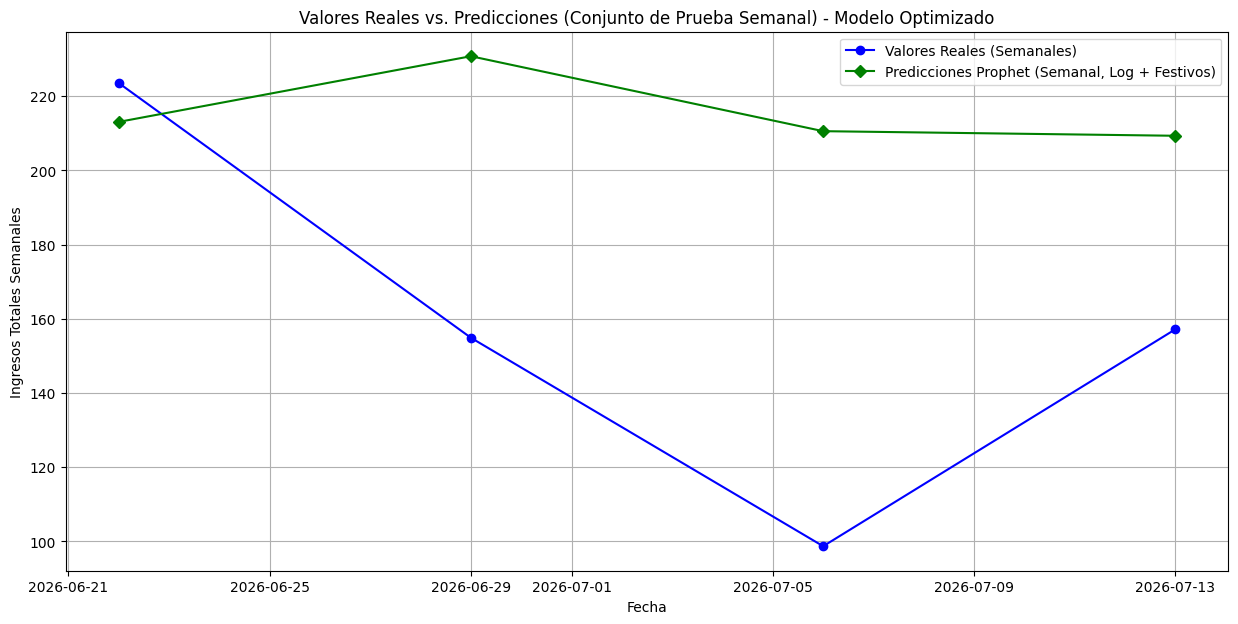

In [142]:
# Visualizar las predicciones del conjunto de prueba vs. valores reales con el modelo semanal
plt.figure(figsize=(15, 7))
plt.plot(performance_weekly_df_log['ds'], performance_weekly_df_log['y_true'], label='Valores Reales (Semanales)', color='blue', marker='o')
plt.plot(performance_weekly_df_log['ds'], performance_weekly_df_log['yhat'], label='Predicciones Prophet (Semanal, Log + Festivos)', color='green', linestyle='-', marker='D')
plt.title('Valores Reales vs. Predicciones (Conjunto de Prueba Semanal) - Modelo Optimizado')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales Semanales')
plt.legend()
plt.grid(True)
plt.show()

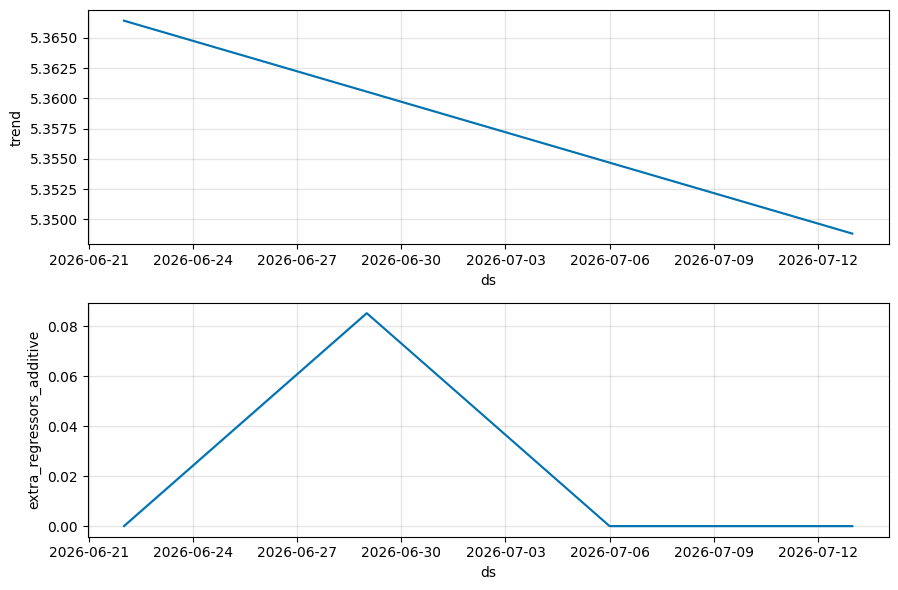

In [143]:
# Visualizar los componentes del pronóstico semanal de Prophet
fig_components_weekly = model_weekly_log_holidays.plot_components(forecast_weekly_log_holidays)
plt.show()

## Predicciones Semanales con un Modelo de Regresión

Ahora, exploraremos un enfoque diferente utilizando un modelo de regresión (Random Forest) para predecir las ventas semanales. Esto nos permitirá comparar el rendimiento con los modelos de Prophet y ver si un enfoque basado en características puede ofrecer mejores resultados.

### 1. Preparación de Datos para el Modelo de Regresión (Features Engineering)

Crearemos características relevantes a partir de nuestros datos semanales, como rezagos de ventas, indicadores de festivos, y componentes de fecha (semana del año, mes, etc.).

In [144]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Usaremos weekly_df_prophet_with_holidays como base, que ya tiene 'ds', 'y', 'is_weekly_national_holiday', 'is_weekly_school_holiday'
weekly_df_reg = weekly_df_prophet_with_holidays.copy()

# Crear features de tiempo
weekly_df_reg['week_of_year'] = weekly_df_reg['ds'].dt.isocalendar().week.astype(int)
weekly_df_reg['month'] = weekly_df_reg['ds'].dt.month
weekly_df_reg['year'] = weekly_df_reg['ds'].dt.year
weekly_df_reg['day_of_week'] = weekly_df_reg['ds'].dt.dayofweek # Lunes=0, Domingo=6

# Crear features de rezago (lag features) para las ventas
# Esto puede ayudar al modelo a aprender de patrones pasados
for i in range(1, 4): # Rezagos de 1, 2 y 3 semanas
    weekly_df_reg[f'y_lag_{i}'] = weekly_df_reg['y'].shift(i)

# Eliminar filas con NaN introducidos por los rezagos
weekly_df_reg.dropna(inplace=True)

print("DataFrame con características de regresión (primeras 5 filas):")
display(weekly_df_reg.head())

DataFrame con características de regresión (primeras 5 filas):


,ds,y,is_weekly_national_holiday,is_weekly_school_holiday,week_of_year,month,year,day_of_week,y_lag_1,y_lag_2,y_lag_3
3,2026-04-06,210.0,1,0,15,4,2026,0,314.6,499.1,70.5
4,2026-04-13,248.5,0,0,16,4,2026,0,210.0,314.6,499.1
5,2026-04-20,475.7,0,0,17,4,2026,0,248.5,210.0,314.6
6,2026-04-27,332.8,0,0,18,4,2026,0,475.7,248.5,210.0
7,2026-05-04,197.6,1,0,19,5,2026,0,332.8,475.7,248.5


### 2. División de Datos (Entrenamiento y Prueba)

In [145]:
# Definir las features (X) y la variable objetivo (y)
features = ['week_of_year', 'month', 'year', 'day_of_week', 'is_weekly_national_holiday', 'is_weekly_school_holiday', 'y_lag_1', 'y_lag_2', 'y_lag_3']
X = weekly_df_reg[features]
y = weekly_df_reg['y']

# Usar el mismo tamaño de conjunto de prueba que para Prophet (test_size_weeks)
# Nos aseguramos de que los datos de prueba sean las últimas 'test_size_weeks' semanas
X_train = X[:-test_size_weeks]
X_test = X[-test_size_weeks:]
y_train = y[:-test_size_weeks]
y_test = y[-test_size_weeks:]

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} semanas")
print(f"Tamaño del conjunto de prueba: {len(X_test)} semanas")

Tamaño del conjunto de entrenamiento: 11 semanas
Tamaño del conjunto de prueba: 4 semanas


### 3. Entrenamiento del Modelo de Regresión (Random Forest)

In [146]:
# Inicializar y entrenar el modelo Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Modelo Random Forest Regressor entrenado.")

Modelo Random Forest Regressor entrenado.


### 4. Predicción y Evaluación del Modelo de Regresión Semanal

In [147]:
# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Asegurarse de que las predicciones sean no-negativas
y_pred_rf = np.maximum(y_pred_rf, 0)

# Calcular RMSE y MAPE
rmse_rf_weekly = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf_weekly = mean_absolute_percentage_error(y_test.replace(0, 1), y_pred_rf)

print(f"Random Forest (semanal) RMSE en el conjunto de prueba: {rmse_rf_weekly:.2f}")
print(f"Random Forest (semanal) MAPE en el conjunto de prueba: {mape_rf_weekly:.2%}")

print(f"\nComparación con los modelos diarios y semanales de Prophet:")
print(f"  Prophet (base) RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2%}")
print(f"  Prophet (con festivos nacionales) RMSE: {rmse_prophet_holidays:.2f}, MAPE: {mape_prophet_holidays:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales) RMSE: {rmse_prophet_log:.2f}, MAPE: {mape_prophet_log:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales y escolares) RMSE: {rmse_prophet_all_holidays:.2f}, MAPE: {mape_prophet_all_holidays:.2%}")
print(f"  Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE: {rmse_prophet_weekly:.2f}, MAPE: {mape_prophet_weekly:.2%}")

Random Forest (semanal) RMSE en el conjunto de prueba: 91.22
Random Forest (semanal) MAPE en el conjunto de prueba: 62.74%

Comparación con los modelos diarios y semanales de Prophet:
  Prophet (base) RMSE: 33.60, MAPE: 312.47%
  Prophet (con festivos nacionales) RMSE: 36.90, MAPE: 489.21%
  Prophet (log-transformado, festivos nacionales) RMSE: 38.37, MAPE: 158.39%
  Prophet (log-transformado, festivos nacionales y escolares) RMSE: 38.37, MAPE: 158.39%
  Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE: 72.65, MAPE: 50.06%


### 5. Visualización del Modelo de Regresión Semanal

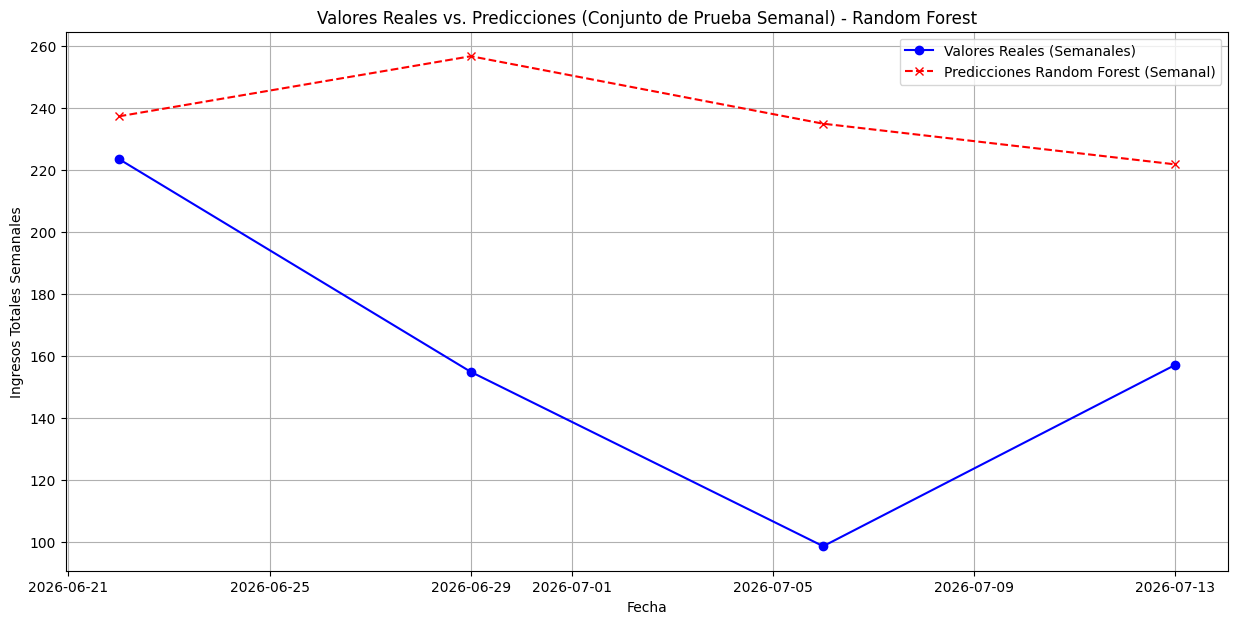

In [148]:
# Crear un DataFrame para visualizar los resultados de RF
results_rf_weekly = pd.DataFrame({'ds': X_test.index, 'y_true': y_test, 'y_pred': y_pred_rf})
results_rf_weekly['ds'] = weekly_df_reg.loc[X_test.index, 'ds'].values # Obtener las fechas reales

plt.figure(figsize=(15, 7))
plt.plot(results_rf_weekly['ds'], results_rf_weekly['y_true'], label='Valores Reales (Semanales)', color='blue', marker='o')
plt.plot(results_rf_weekly['ds'], results_rf_weekly['y_pred'], label='Predicciones Random Forest (Semanal)', color='red', linestyle='--', marker='x')
plt.title('Valores Reales vs. Predicciones (Conjunto de Prueba Semanal) - Random Forest')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales Semanales')
plt.legend()
plt.grid(True)
plt.show()

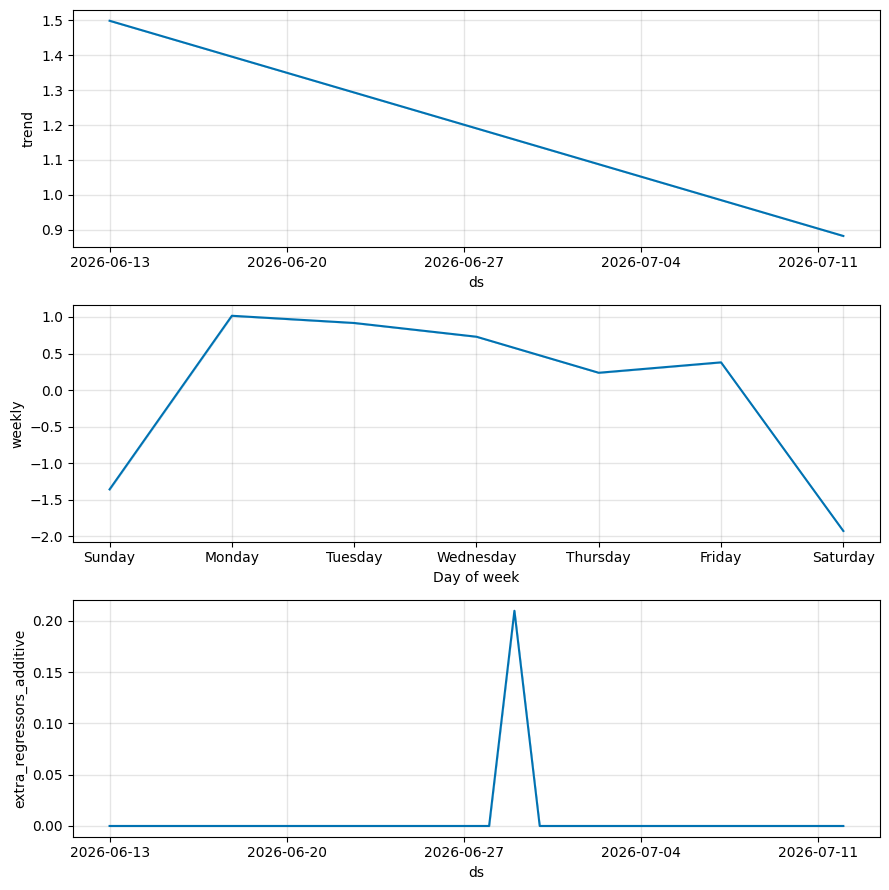

In [149]:
# Visualizar los componentes del pronóstico de Prophet con todos los regresores
fig_components_all_holidays = model_log_all_holidays.plot_components(forecast_log_all_holidays)
plt.show()

## Implementación del Modelo Prophet Semanal Optimizado

Este apartado consolida el código y la explicación del modelo Prophet que logró el mejor rendimiento para la predicción de ventas semanales, incorporando:

*   **Agregación de datos a nivel semanal:** Para capturar patrones semanales de manera más efectiva.
*   **Transformación logarítmica (`np.log1p`):** Para estabilizar la varianza y manejar la estacionalidad multiplicativa.
*   **Regresores externos de festivos nacionales:** Para contabilizar el impacto de días feriados.
*   **Regresores externos de vacaciones y campañas escolares:** Para considerar los periodos clave del calendario educativo.

El objetivo es proporcionar un modelo robusto y comprensible para futuras predicciones.

### 1. Carga de Datos y Preparación Inicial

Primero, aseguramos que los datos diarios estén cargados y preprocesados, incluyendo el manejo de fechas y el relleno de días sin ventas.

In [150]:
import pandas as pd
import numpy as np
from prophet import Prophet
from dateutil import parser
import holidays # Para manejar días festivos nacionales
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import matplotlib.pyplot as plt

# --- Código para cargar y preparar ingreso_diario_completo (replicado de FoJ6TqTslijr) ---

# 1. Cargar el archivo de ventas
try:
    # Se especifica sep=';' para manejar el delimitador de punto y coma
    df_ventas = pd.read_csv('ventas.csv', sep=';')
    print("Archivo 'ventas.csv' cargado exitosamente.")
except FileNotFoundError:
    print("Error: 'ventas.csv' no encontrado. Por favor, asegúrate de que el archivo esté en la ruta correcta.")
    df_ventas = pd.DataFrame({'Fecha': [], 'Total': []})

# 2. Normalización de Fechas
def parsear_fechas_cronologicas(fechas):
        fechas_limpias = []
        fecha_anterior = pd.Timestamp.min

        for fecha_str in fechas:
            if pd.isna(fecha_str):
                fechas_limpias.append(pd.NaT)
                continue

            try:
                fecha_dia_primero = parser.parse(fecha_str, dayfirst=True)
                fecha_mes_primero = parser.parse(fecha_str, dayfirst=False)

                if fecha_dia_primero == fecha_mes_primero:
                    fecha_elegida = fecha_dia_primero
                else:
                    valido_dia = fecha_dia_primero >= fecha_anterior
                    valido_mes = fecha_mes_primero >= fecha_anterior

                    if valido_dia and not valido_mes:
                        fecha_elegida = fecha_dia_primero
                    elif valido_mes and not valido_dia:
                        fecha_elegida = fecha_mes_primero
                    elif valido_dia and valido_mes:
                        if (fecha_dia_primero - fecha_anterior) < (fecha_mes_primero - fecha_anterior):
                            fecha_elegida = fecha_dia_primero
                        else:
                            fecha_elegida = fecha_mes_primero
                    else:
                        diff_dia = fecha_anterior - fecha_dia_primero
                        diff_mes = fecha_anterior - fecha_mes_primero
                        fecha_elegida = fecha_dia_primero if diff_dia < diff_mes else fecha_mes_primero

                fechas_limpias.append(fecha_elegida)
                fecha_anterior = fecha_elegida

            except Exception:
                fechas_limpias.append(pd.NaT)

        return fechas_limpias

# Asegurarse de que las columnas necesarias existan
if 'Fecha' not in df_ventas.columns or 'Total' not in df_ventas.columns:
    print("Error: Las columnas 'Fecha' o 'Total' no se encontraron en el DataFrame. Por favor, verifica el archivo CSV y el delimitador usado.")
    ingreso_diario_completo = pd.DataFrame(columns=['Ingreso_Total'], index=pd.Index([], name='Fecha_Diaria'))
else:
    # Aplicación del algoritmo
    df_ventas['Fecha_Estandar'] = parsear_fechas_cronologicas(df_ventas['Fecha'])
    df_ventas['Fecha_Estandar'] = pd.to_datetime(df_ventas['Fecha_Estandar'])
    df_ventas.dropna(subset=['Fecha_Estandar'], inplace=True)
    df_ventas['Fecha_Diaria'] = df_ventas['Fecha_Estandar'].dt.normalize()

    print("Fechas normalizadas a formato diario (YYYY-MM-DD).")

    # 3. Agrupación (Ingreso Diario)
    ingreso_diario = df_ventas.groupby('Fecha_Diaria')['Total'].sum().reset_index()
    ingreso_diario.rename(columns={'Total': 'Ingreso_Total'}, inplace=True)
    ingreso_diario.set_index('Fecha_Diaria', inplace=True)
    print("Ingreso diario calculado.")

    # 4. Manejo de días sin ventas (rellenar con 0)
    if not ingreso_diario.empty:
        min_date_daily = ingreso_diario.index.min()
        max_date_daily = ingreso_diario.index.max()
        full_date_range_daily = pd.date_range(start=min_date_daily, end=max_date_daily, freq='D')
        ingreso_diario_completo = ingreso_diario.reindex(full_date_range_daily, fill_value=0)
        ingreso_diario_completo.index.name = 'Fecha_Diaria'
        print("Días sin ventas rellenados con 0.")
    else:
        print("No hay datos para calcular el ingreso diario o para rellenar días sin ventas.")
        ingreso_diario_completo = pd.DataFrame(columns=['Ingreso_Total'], index=pd.Index([], name='Fecha_Diaria'))

print("\nPrimeras 5 filas del ingreso diario completo:")
display(ingreso_diario_completo.head())

Archivo 'ventas.csv' cargado exitosamente.
Fechas normalizadas a formato diario (YYYY-MM-DD).
Ingreso diario calculado.
Días sin ventas rellenados con 0.

Primeras 5 filas del ingreso diario completo:


,Ingreso_Total
Fecha_Diaria,
2026-03-15,40.2
2026-03-16,30.3
2026-03-17,60.9
2026-03-18,234.5
2026-03-19,89.6


### 2. Agregación Semanal y Creación de Regresores de Festivos

Transformamos los datos diarios a semanales y preparamos los indicadores de festivos nacionales y escolares a nivel semanal.

In [151]:
# 1. Agrupar 'ingreso_diario_completo' por semana y sumar los ingresos
weekly_ingreso = ingreso_diario_completo.resample('W-MON')['Ingreso_Total'].sum().reset_index()

# Renombrar columnas para Prophet
weekly_df_prophet = weekly_ingreso.rename(columns={'Fecha_Diaria': 'ds', 'Ingreso_Total': 'y'})

# Asegurarse de que 'ds' sea datetime y 'y' sea numérico
weekly_df_prophet['ds'] = pd.to_datetime(weekly_df_prophet['ds'])
weekly_df_prophet['y'] = pd.to_numeric(weekly_df_prophet['y'])

# 2. Crear indicadores semanales para festivos nacionales y escolares
min_date_h = weekly_df_prophet['ds'].min()
max_date_h = weekly_df_prophet['ds'].max()

# Festivos nacionales
pe_holidays_combined = holidays.country_holidays('PE', years=range(min_date_h.year, max_date_h.year + 1))
holidays_df_national = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in pe_holidays_combined.items()
])
holidays_df_national['ds'] = pd.to_datetime(holidays_df_national['ds'])
weekly_national_holidays = holidays_df_national.set_index('ds').resample('W-MON').apply(lambda x: 1 if len(x) > 0 else 0).rename(columns={'holiday': 'is_weekly_national_holiday'}).reset_index()

# Festivos escolares (se usan las mismas fechas hipotéticas definidas anteriormente)
school_holidays_data = [
    {'holiday': 'Vacaciones de Verano', 'ds': '2026-01-01', 'upper_window': 0, 'lower_window': 58},
    {'holiday': 'Campaña Escolar Inicio', 'ds': '2026-03-01', 'upper_window': 7, 'lower_window': 30},
    {'holiday': 'Vacaciones de Medio Año', 'ds': '2026-07-26', 'upper_window': 7, 'lower_window': 14},
    {'holiday': 'Campaña Escolar Fiestas Patrias', 'ds': '2026-07-28', 'upper_window': 7, 'lower_window': 7},
    {'holiday': 'Vacaciones de Fin de Año', 'ds': '2026-12-15', 'upper_window': 15, 'lower_window': 0},
    {'holiday': 'Campaña Escolar Navidad', 'ds': '2026-12-01', 'upper_window': 24, 'lower_window': 0}
]
school_holidays_df = pd.DataFrame(school_holidays_data)
school_holidays_df['ds'] = pd.to_datetime(school_holidays_df['ds'])

# Expandir las fechas de las vacaciones/campañas escolares a un rango diario
school_campaign_daily_dates = []
for _, row in school_holidays_df.iterrows():
    start_date = row['ds'] - pd.Timedelta(days=row['lower_window'])
    end_date = row['ds'] + pd.Timedelta(days=row['upper_window'])
    current_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    school_campaign_daily_dates.extend(current_dates)

school_campaign_daily_df = pd.DataFrame({'ds': list(set(school_campaign_daily_dates))}) # Eliminar duplicados
school_campaign_daily_df['is_school_campaign_day'] = 1
school_campaign_daily_df['ds'] = pd.to_datetime(school_campaign_daily_df['ds'])

# Resample a semanal para ver si alguna semana contiene un día de vacaciones/campaña escolar
weekly_school_holidays = school_campaign_daily_df.set_index('ds').resample('W-MON').apply(lambda x: 1 if len(x) > 0 else 0).rename(columns={'is_school_campaign_day': 'is_weekly_school_holiday'}).reset_index()

# Unir los regresores semanales al dataframe semanal
weekly_df_prophet_with_holidays = pd.merge(weekly_df_prophet, weekly_national_holidays, on='ds', how='left')
weekly_df_prophet_with_holidays = pd.merge(weekly_df_prophet_with_holidays, weekly_school_holidays, on='ds', how='left')

# Rellenar NaNs con 0 para los regresores
weekly_df_prophet_with_holidays['is_weekly_national_holiday'] = weekly_df_prophet_with_holidays['is_weekly_national_holiday'].fillna(0).astype(int)
weekly_df_prophet_with_holidays['is_weekly_school_holiday'] = weekly_df_prophet_with_holidays['is_weekly_school_holiday'].fillna(0).astype(int)

print("Datos semanales con regresores de festivos (primeras 5 filas):")
display(weekly_df_prophet_with_holidays.head())

Datos semanales con regresores de festivos (primeras 5 filas):


,ds,y,is_weekly_national_holiday,is_weekly_school_holiday
0,2026-03-16,70.5,0,0
1,2026-03-23,499.1,0,0
2,2026-03-30,314.6,0,0
3,2026-04-06,210.0,1,0
4,2026-04-13,248.5,0,0


### 3. Aplicación de la Transformación Logarítmica

Para estabilizar la varianza y mejorar el ajuste del modelo, aplicamos la transformación logarítmica (`np.log1p`) a la variable objetivo `y`.

In [152]:
# Aplicar np.log1p a la columna 'y' de los datos semanales
weekly_df_prophet_log = weekly_df_prophet_with_holidays.copy()
weekly_df_prophet_log['y'] = np.log1p(weekly_df_prophet_log['y'])

print("DataFrame semanal con 'y' transformada logarítmicamente (primeras 5 filas):")
display(weekly_df_prophet_log.head())

DataFrame semanal con 'y' transformada logarítmicamente (primeras 5 filas):


,ds,y,is_weekly_national_holiday,is_weekly_school_holiday
0,2026-03-16,4.269697,0,0
1,2026-03-23,6.214808,0,0
2,2026-03-30,5.754476,0,0
3,2026-04-06,5.351858,1,0
4,2026-04-13,5.519459,0,0


### 4. División de Datos y Entrenamiento del Modelo Prophet

Dividimos los datos en conjuntos de entrenamiento y prueba y procedemos a entrenar el modelo Prophet con los datos log-transformados y los regresores de festivos semanales.

In [153]:
# Definir el tamaño del conjunto de prueba en semanas
test_size_weeks = 4

# Dividir los datos semanales transformados para entrenamiento y evaluación
train_weekly_df_log = weekly_df_prophet_log[:-test_size_weeks]
test_weekly_df_original_y = weekly_df_prophet_with_holidays[-test_size_weeks:] # Guardar y original para evaluación

# Re-entrenar el modelo Prophet con el conjunto de entrenamiento semanal logarítmico
model_weekly_log_holidays = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=False, # No aplicar estacionalidad semanal, ya está en la agregación
    daily_seasonality=False,
    yearly_seasonality=False # Ajustar según la longitud de los datos
)

# Añadir los regresores extras para los días festivos nacionales y escolares (semanales)
model_weekly_log_holidays.add_regressor('is_weekly_national_holiday')
model_weekly_log_holidays.add_regressor('is_weekly_school_holiday')

model_weekly_log_holidays.fit(train_weekly_df_log)

print("Modelo Prophet re-entrenado con datos logarítmicos, festivos nacionales y escolares semanales.")

INFO:prophet:n_changepoints greater than number of observations. Using 10.


Modelo Prophet re-entrenado con datos logarítmicos, festivos nacionales y escolares semanales.


### 5. Generación de Predicciones y Transformación Inversa

Realizamos las predicciones sobre el conjunto de prueba en la escala logarítmica y luego revertimos la transformación a la escala original para su interpretación.

In [154]:
# Crear un dataframe de fechas futuras para la predicción (conjunto de prueba semanal)
future_eval_weekly_holidays = model_weekly_log_holidays.make_future_dataframe(periods=test_size_weeks, freq='W-MON', include_history=False)

# Añadir los regresores semanales al dataframe futuro
future_eval_weekly_holidays = pd.merge(future_eval_weekly_holidays, weekly_national_holidays, on='ds', how='left')
future_eval_weekly_holidays = pd.merge(future_eval_weekly_holidays, weekly_school_holidays, on='ds', how='left')

# Rellenar NaNs con 0 para los regresores en el dataframe futuro
future_eval_weekly_holidays['is_weekly_national_holiday'] = future_eval_weekly_holidays['is_weekly_national_holiday'].fillna(0).astype(int)
future_eval_weekly_holidays['is_weekly_school_holiday'] = future_eval_weekly_holidays['is_weekly_school_holiday'].fillna(0).astype(int)

# Realizar la predicción en escala logarítmica
forecast_weekly_log_holidays = model_weekly_log_holidays.predict(future_eval_weekly_holidays)

# Revertir la transformación logarítmica a la escala original (expm1 es la inversa de log1p)
forecast_weekly_log_holidays['yhat_original'] = np.expm1(forecast_weekly_log_holidays['yhat'])
forecast_weekly_log_holidays['yhat_lower_original'] = np.expm1(forecast_weekly_log_holidays['yhat_lower'])
forecast_weekly_log_holidays['yhat_upper_original'] = np.expm1(forecast_weekly_log_holidays['yhat_upper'])

# Asegurarse de que las predicciones originales sean no-negativas
forecast_weekly_log_holidays['yhat_original'] = forecast_weekly_log_holidays['yhat_original'].apply(lambda x: max(x, 0))
forecast_weekly_log_holidays['yhat_lower_original'] = forecast_weekly_log_holidays['yhat_lower_original'].apply(lambda x: max(x, 0))
forecast_weekly_log_holidays['yhat_upper_original'] = forecast_weekly_log_holidays['yhat_upper_original'].apply(lambda x: max(x, 0))

print("Predicciones semanales generadas y revertidas a escala original (primeras 5 filas):")
display(forecast_weekly_log_holidays[['ds', 'yhat_original', 'yhat_lower_original', 'yhat_upper_original']].head())

Predicciones semanales generadas y revertidas a escala original (primeras 5 filas):


,ds,yhat_original,yhat_lower_original,yhat_upper_original
0,2026-06-22,213.095180,108.859431,421.808289
1,2026-06-29,230.806008,123.552171,440.437001
2,2026-07-06,210.597634,107.042471,400.661178
3,2026-07-13,209.359808,105.025358,401.048638


### 6. Evaluación del Modelo Prophet Semanal

> Añadir blockquote



Calculamos las métricas de rendimiento (RMSE y MAPE) para el modelo en la escala original y las comparamos con los resultados de otros modelos Prophet.

In [155]:
# Unir las predicciones semanales con los valores reales del conjunto de prueba (originales)
performance_weekly_df_log = pd.merge(test_weekly_df_original_y, forecast_weekly_log_holidays[['ds', 'yhat_original']], on='ds', how='left')
performance_weekly_df_log = performance_weekly_df_log.rename(columns={'y': 'y_true', 'yhat_original': 'yhat'})

# Asegurarse de que no haya NaN en las predicciones si merge falló
performance_weekly_df_log.dropna(subset=['y_true', 'yhat'], inplace=True)

# Calcular RMSE para el modelo semanal con transformación logarítmica y todos los festivos
rmse_prophet_weekly = np.sqrt(mean_squared_error(performance_weekly_df_log['y_true'], performance_weekly_df_log['yhat']))

# Calcular MAPE para el modelo semanal con transformación logarítmica y todos los festivos
mape_prophet_weekly = mean_absolute_percentage_error(performance_weekly_df_log['y_true'].replace(0, 1), performance_weekly_df_log['yhat'])

print(f"Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE en el conjunto de prueba: {rmse_prophet_weekly:.2f}")
print(f"Prophet (semanal, log-transformado, festivos nacionales y escolares) MAPE en el conjunto de prueba: {mape_prophet_weekly:.2%}")

# Replicar las variables de métricas de los modelos diarios para la comparación
# Asegúrate de que estas variables (rmse_prophet, mape_prophet, etc.) estén definidas en celdas anteriores
# o replicadas aquí si este bloque debe ser completamente autocontenido.
# Por simplicidad, asumimos que ya fueron calculadas y están disponibles en el entorno.

print(f"\nComparación con los modelos diarios:")
print(f"  Prophet (base) RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2%}")
print(f"  Prophet (con festivos nacionales) RMSE: {rmse_prophet_holidays:.2f}, MAPE: {mape_prophet_holidays:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales) RMSE: {rmse_prophet_log:.2f}, MAPE: {mape_prophet_log:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales y escolares) RMSE: {rmse_prophet_all_holidays:.2f}, MAPE: {mape_prophet_all_holidays:.2%}")

Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE en el conjunto de prueba: 72.65
Prophet (semanal, log-transformado, festivos nacionales y escolares) MAPE en el conjunto de prueba: 50.06%

Comparación con los modelos diarios:
  Prophet (base) RMSE: 33.60, MAPE: 312.47%
  Prophet (con festivos nacionales) RMSE: 36.90, MAPE: 489.21%
  Prophet (log-transformado, festivos nacionales) RMSE: 38.37, MAPE: 158.39%
  Prophet (log-transformado, festivos nacionales y escolares) RMSE: 38.37, MAPE: 158.39%


### 7. Visualización del Modelo Prophet Semanal

Graficamos las predicciones del modelo Prophet semanal frente a los valores reales para el conjunto de prueba, así como los componentes del pronóstico.

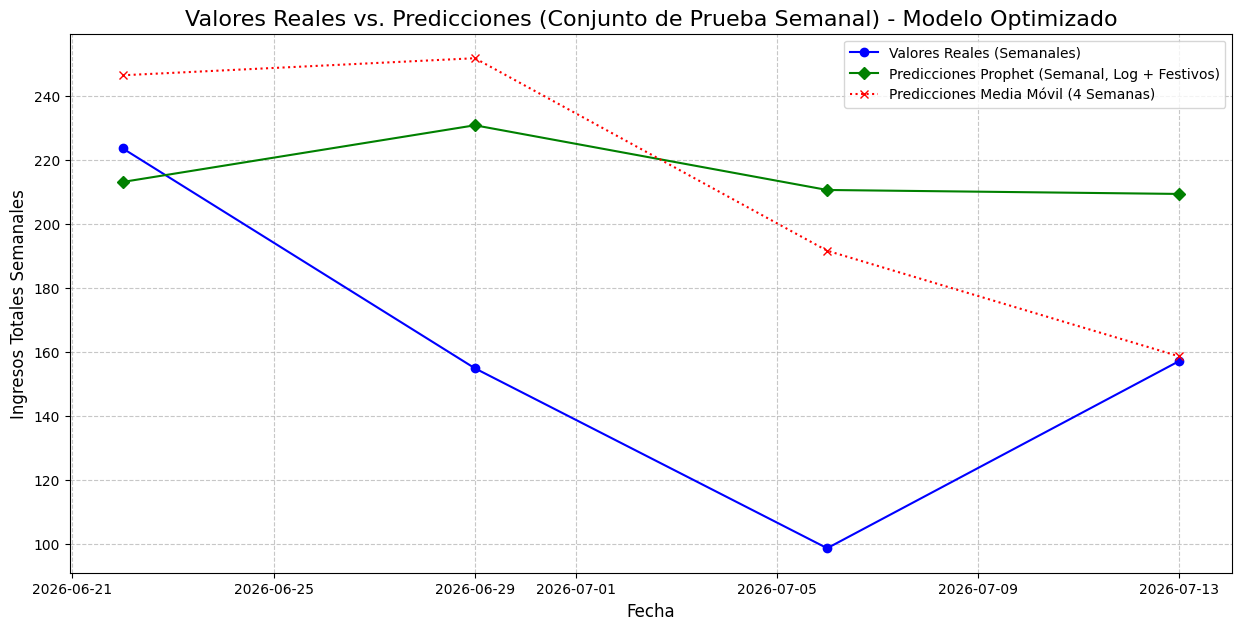

In [164]:
import matplotlib.pyplot as plt

# Asumiendo que ma_predictions_test y performance_weekly_df_log['ds'] están disponibles
# Si no, deberíamos cargarlos o recrearlos aquí.

# Visualizar las predicciones del conjunto de prueba vs. valores reales con el modelo semanal
plt.figure(figsize=(15, 7))
plt.plot(performance_weekly_df_log['ds'], performance_weekly_df_log['y_true'], label='Valores Reales (Semanales)', color='blue', marker='o')
plt.plot(performance_weekly_df_log['ds'], performance_weekly_df_log['yhat'], label='Predicciones Prophet (Semanal, Log + Festivos)', color='green', linestyle='-', marker='D')

# Añadir las predicciones de la media móvil
plt.plot(performance_weekly_df_log['ds'], ma_predictions_test, label='Predicciones Media Móvil (4 Semanas)', color='red', linestyle=':', marker='x')

plt.title('Valores Reales vs. Predicciones (Conjunto de Prueba Semanal) - Modelo Optimizado', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Ingresos Totales Semanales', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

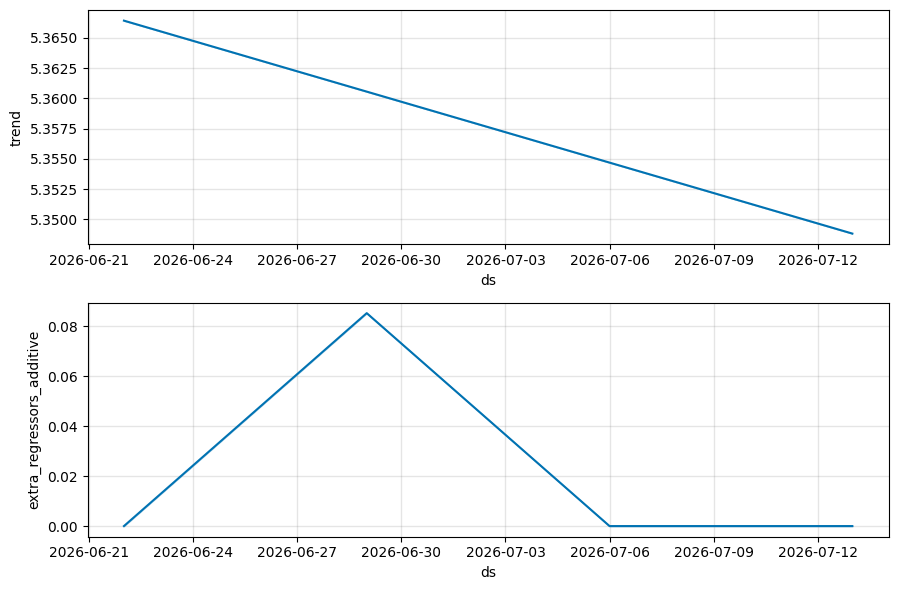

In [157]:
# Visualizar los componentes del pronóstico semanal de Prophet
fig_components_weekly = model_weekly_log_holidays.plot_components(forecast_weekly_log_holidays)
plt.show()

## Aplicación del Modelo Prophet Semanal Optimizado: Predicciones Futuras

Una vez que hemos entrenado y evaluado el modelo Prophet semanal, log-transformado y con regresores de festivos nacionales y escolares, el siguiente paso es utilizarlo para generar pronósticos sobre períodos futuros. Esto es crucial para la planificación estratégica y la toma de decisiones.

A continuación, se muestra cómo generar un pronóstico para las próximas 8 semanas utilizando este modelo.

In [158]:
# 1. Crear un dataframe con las fechas futuras para la predicción
# Generaremos predicciones para las próximas 8 semanas
periods_future_weeks = 8

# Asegurarse de que el dataframe futuro comienza después de la última fecha de entrenamiento
# La última fecha en weekly_df_prophet_log es el final del período histórico.
# make_future_dataframe() por defecto incluye la historia, pero la sobrescribiremos con solo el futuro
last_date_in_data = weekly_df_prophet_log['ds'].max()
future_weekly_df = model_weekly_log_holidays.make_future_dataframe(periods=periods_future_weeks, freq='W-MON', include_history=False)

# 2. Añadir los regresores semanales al dataframe futuro
# Para esto, necesitamos generar los indicadores de festivos para las fechas futuras
min_date_future = future_weekly_df['ds'].min()
max_date_future = future_weekly_df['ds'].max()

# Festivos nacionales para el rango futuro
future_national_holidays_combined = holidays.country_holidays('PE', years=range(min_date_future.year, max_date_future.year + 1))
future_holidays_df_national = pd.DataFrame([
    {'ds': date, 'holiday': name}
    for date, name in future_national_holidays_combined.items()
])
future_holidays_df_national['ds'] = pd.to_datetime(future_holidays_df_national['ds'])

future_weekly_national_holidays = future_holidays_df_national.set_index('ds').resample('W-MON').apply(lambda x: 1 if len(x) > 0 else 0).rename(columns={'holiday': 'is_weekly_national_holiday'}).reset_index()

# Festivos escolares para el rango futuro (usando las mismas definiciones de school_holidays_df)
# Expandir las fechas de las vacaciones/campañas escolares a un rango diario
future_school_campaign_daily_dates = []
for _, row in school_holidays_df.iterrows():
    start_date = row['ds'] - pd.Timedelta(days=row['lower_window'])
    end_date = row['ds'] + pd.Timedelta(days=row['upper_window'])
    current_dates = pd.date_range(start=start_date, end=end_date, freq='D')
    future_school_campaign_daily_dates.extend(current_dates)

future_school_campaign_daily_df = pd.DataFrame({'ds': list(set(future_school_campaign_daily_dates))}) # Eliminar duplicados
future_school_campaign_daily_df['is_school_campaign_day'] = 1
future_school_campaign_daily_df['ds'] = pd.to_datetime(future_school_campaign_daily_df['ds'])

# Resample a semanal para ver si alguna semana contiene un día de vacaciones/campaña escolar
future_weekly_school_holidays = future_school_campaign_daily_df.set_index('ds').resample('W-MON').apply(lambda x: 1 if len(x) > 0 else 0).rename(columns={'is_school_campaign_day': 'is_weekly_school_holiday'}).reset_index()

# Unir los regresores semanales al dataframe futuro
future_weekly_df = pd.merge(future_weekly_df, future_weekly_national_holidays, on='ds', how='left')
future_weekly_df = pd.merge(future_weekly_df, future_weekly_school_holidays, on='ds', how='left')

# Rellenar NaNs con 0 para los regresores en el dataframe futuro (si hay semanas sin festivos)
future_weekly_df['is_weekly_national_holiday'] = future_weekly_df['is_weekly_national_holiday'].fillna(0).astype(int)
future_weekly_df['is_weekly_school_holiday'] = future_weekly_df['is_weekly_school_holiday'].fillna(0).astype(int)

# 3. Realizar la predicción en escala logarítmica
forecast_future = model_weekly_log_holidays.predict(future_weekly_df)

# 4. Revertir la transformación logarítmica a la escala original
forecast_future['yhat_original'] = np.expm1(forecast_future['yhat'])
forecast_future['yhat_lower_original'] = np.expm1(forecast_future['yhat_lower'])
forecast_future['yhat_upper_original'] = np.expm1(forecast_future['yhat_upper'])

# Asegurarse de que las predicciones originales sean no-negativas
forecast_future['yhat_original'] = forecast_future['yhat_original'].apply(lambda x: max(x, 0))
forecast_future['yhat_lower_original'] = forecast_future['yhat_lower_original'].apply(lambda x: max(x, 0))
forecast_future['yhat_upper_original'] = forecast_future['yhat_upper_original'].apply(lambda x: max(x, 0))

print(f"Predicciones semanales futuras para las próximas {periods_future_weeks} semanas:")
display(forecast_future[['ds', 'yhat_original', 'yhat_lower_original', 'yhat_upper_original']])

Predicciones semanales futuras para las próximas 8 semanas:


,ds,yhat_original,yhat_lower_original,yhat_upper_original
0,2026-06-22,213.095180,113.088452,427.580876
1,2026-06-29,230.806008,113.839328,422.282468
2,2026-07-06,210.597634,111.394248,385.816856
3,2026-07-13,209.359808,105.122052,417.759313
4,2026-07-20,208.129223,105.860239,377.773714
5,2026-07-27,225.429247,117.754086,439.648690
6,2026-08-03,224.104657,114.959758,415.396958
7,2026-08-10,222.787817,116.804952,421.265672


## Visualización de las Predicciones Futuras

Para facilitar la interpretación, visualizamos las predicciones futuras junto con el historial de ventas para entender la tendencia y los patrones proyectados.

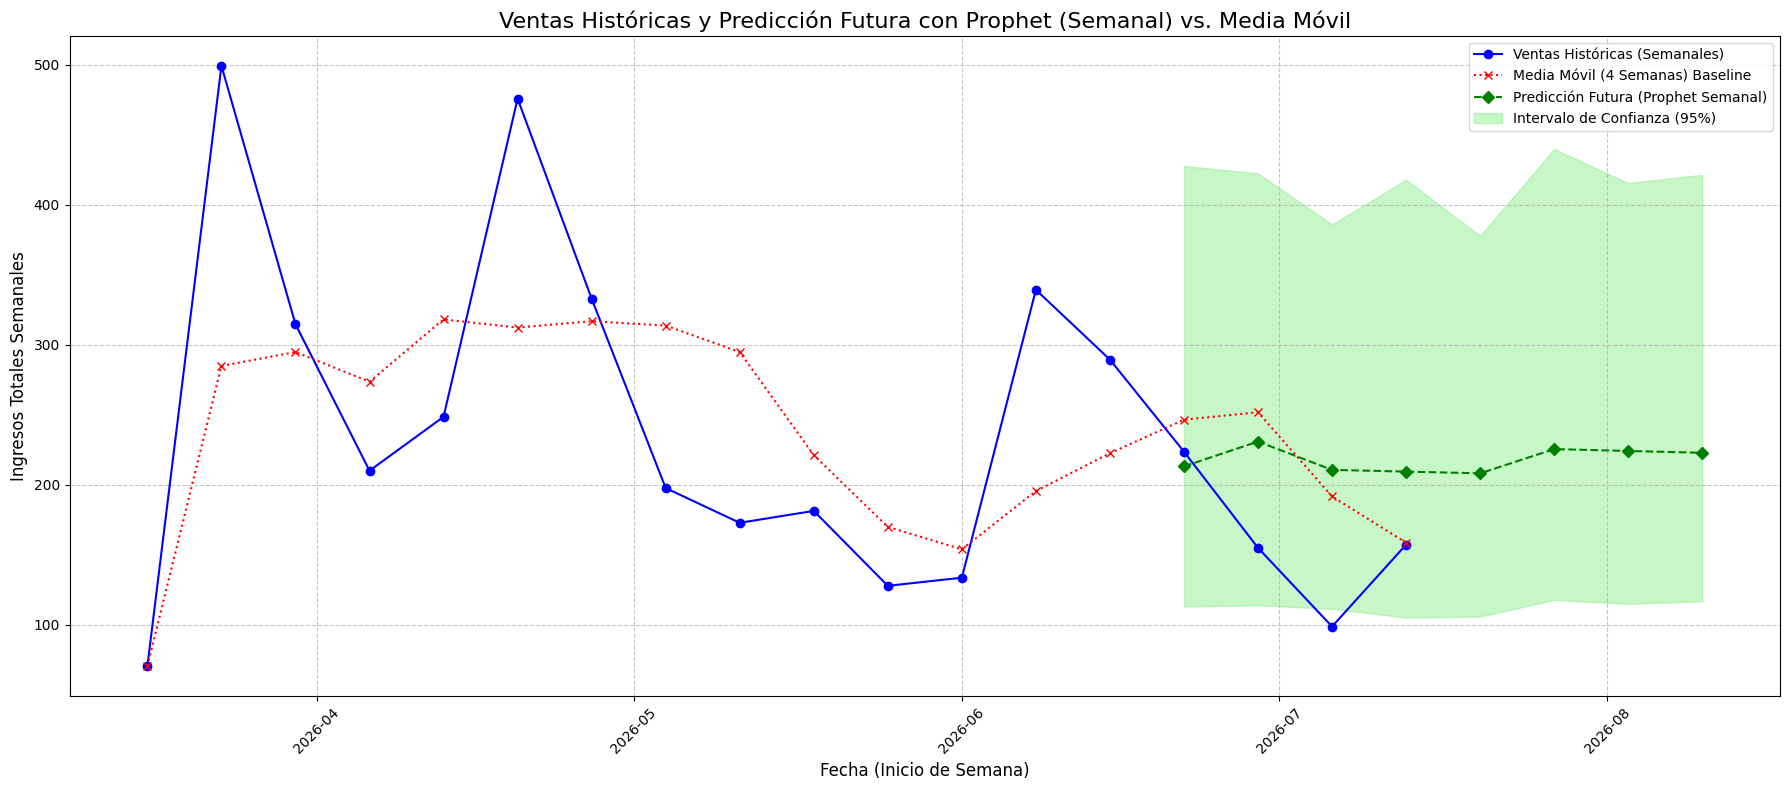

In [159]:
import matplotlib.pyplot as plt

# Unir los datos históricos con las predicciones futuras para la visualización
# Necesitamos el dataframe original con los valores de 'y' para el historial

# Crear un DataFrame con los datos históricos de 'y'
history_for_plot = weekly_df_prophet_with_holidays[['ds', 'y']].rename(columns={'y': 'y_true'})

# Calcular la media móvil de 4 semanas como baseline
history_for_plot['moving_average_4w'] = history_for_plot['y_true'].rolling(window=4, min_periods=1).mean()

# Combinar los datos históricos y las predicciones futuras
full_forecast_plot = pd.concat([history_for_plot, forecast_future[['ds', 'yhat_original']].rename(columns={'yhat_original': 'y_true'})], ignore_index=True)

plt.figure(figsize=(18, 8))

# Plotear los datos históricos
plt.plot(history_for_plot['ds'], history_for_plot['y_true'], label='Ventas Históricas (Semanales)', color='blue', marker='o', linestyle='-')

# Plotear la media móvil como baseline
plt.plot(history_for_plot['ds'], history_for_plot['moving_average_4w'], label='Media Móvil (4 Semanas) Baseline', color='red', linestyle=':', marker='x')

# Plotear las predicciones futuras (solo yhat_original)
plt.plot(forecast_future['ds'], forecast_future['yhat_original'], label='Predicción Futura (Prophet Semanal)', color='green', linestyle='--', marker='D')

# Plotear los intervalos de confianza (bandas de sombra)
plt.fill_between(forecast_future['ds'], forecast_future['yhat_lower_original'], forecast_future['yhat_upper_original'], color='lightgreen', alpha=0.5, label='Intervalo de Confianza (95%)')

plt.title('Ventas Históricas y Predicción Futura con Prophet (Semanal) vs. Media Móvil', fontsize=16)
plt.xlabel('Fecha (Inicio de Semana)', fontsize=12)
plt.ylabel('Ingresos Totales Semanales', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [162]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# Extract the relevant portion of history_for_plot for the test period
history_for_plot_test_period = history_for_plot.tail(test_size_weeks)

# True values for the test period
y_true_ma = history_for_plot_test_period['y_true']

# Moving average predictions for the test period
ma_predictions_test = history_for_plot_test_period['moving_average_4w']

# Calculate RMSE for the moving average
rmse_moving_average = np.sqrt(mean_squared_error(y_true_ma, ma_predictions_test))

# Calculate MAPE for the moving average
mape_moving_average = mean_absolute_percentage_error(y_true_ma.replace(0, 1), ma_predictions_test)

print(f"Media Móvil (4 Semanas) RMSE en el conjunto de prueba: {rmse_moving_average:.2f}")
print(f"Media Móvil (4 Semanas) MAPE en el conjunto de prueba: {mape_moving_average:.2%}")

Media Móvil (4 Semanas) RMSE en el conjunto de prueba: 68.08
Media Móvil (4 Semanas) MAPE en el conjunto de prueba: 41.94%


In [163]:
# Re-print the comparison table to include the new moving average metrics.

print(f"\nComparación de modelos:")
print(f"  Prophet (base) RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2%}")
print(f"  Prophet (con festivos nacionales) RMSE: {rmse_prophet_holidays:.2f}, MAPE: {mape_prophet_holidays:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales) RMSE: {rmse_prophet_log:.2f}, MAPE: {mape_prophet_log:.2%}")
print(f"  Prophet (log-transformado, festivos nacionales y escolares) RMSE: {rmse_prophet_all_holidays:.2f}, MAPE: {mape_prophet_all_holidays:.2%}")
print(f"  Media Móvil (4 Semanas) RMSE: {rmse_moving_average:.2f}, MAPE: {mape_moving_average:.2%}")
print(f"  Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE: {rmse_prophet_weekly:.2f}, MAPE: {mape_prophet_weekly:.2%}")
print(f"  Random Forest (semanal) RMSE: {rmse_rf_weekly:.2f}, MAPE: {mape_rf_weekly:.2%}")


Comparación de modelos:
  Prophet (base) RMSE: 33.60, MAPE: 312.47%
  Prophet (con festivos nacionales) RMSE: 36.90, MAPE: 489.21%
  Prophet (log-transformado, festivos nacionales) RMSE: 38.37, MAPE: 158.39%
  Prophet (log-transformado, festivos nacionales y escolares) RMSE: 38.37, MAPE: 158.39%
  Media Móvil (4 Semanas) RMSE: 68.08, MAPE: 41.94%
  Prophet (semanal, log-transformado, festivos nacionales y escolares) RMSE: 72.65, MAPE: 50.06%
  Random Forest (semanal) RMSE: 91.22, MAPE: 62.74%


In [160]:
import joblib
import os

# Crear un directorio para guardar los modelos si no existe
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

# Definir la ruta del archivo para guardar el modelo
model_filename = os.path.join(model_dir, 'prophet_weekly_model.joblib')

# Guardar el modelo
joblib.dump(model_weekly_log_holidays, model_filename)

print(f"Modelo guardado exitosamente en: {model_filename}")

Modelo guardado exitosamente en: trained_models/prophet_weekly_model.joblib
